In [1]:
# 1. 라이브러리 / 경로 설정

import os
import copy
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SAVE_DIR = "stm_gcn_30s_onestep_artifacts"

if not os.path.exists(SAVE_DIR):
    raise FileNotFoundError(f"저장 폴더를 찾을 수 없습니다: {SAVE_DIR}")

print("artifact files:")
print(os.listdir(SAVE_DIR))

device: cuda
artifact files:
['graph_info.pkl', 'onestep_model_checkpoint.pt', 'prediction_results.pkl', 'training_history.pkl', 'x_scaler.pkl', 'y_scaler.pkl']


In [2]:
# 2. 설정 / scaler / graph info / 예측 결과 불러오기

checkpoint = torch.load(
    os.path.join(SAVE_DIR, "onestep_model_checkpoint.pt"),
    map_location=device
)

feature_cols = checkpoint["feature_cols"]
target_cols = checkpoint["target_cols"]

STEP_SECONDS = checkpoint["step_seconds"]
SEQ_LEN = checkpoint["seq_len"]
FORECAST_SECONDS_LIST = checkpoint["forecast_seconds_list"]
MAX_FORECAST_SECONDS = checkpoint["max_forecast_seconds"]
TOLERANCE_SECONDS = checkpoint["tolerance_seconds"]

x_scaler = joblib.load(os.path.join(SAVE_DIR, "x_scaler.pkl"))
y_scaler = joblib.load(os.path.join(SAVE_DIR, "y_scaler.pkl"))

graph_info = joblib.load(os.path.join(SAVE_DIR, "graph_info.pkl"))

transition_counts = graph_info["transition_counts"]
train_lat_min = graph_info["train_lat_min"]
train_lon_min = graph_info["train_lon_min"]
TRAIN_GRID_NM = graph_info["TRAIN_GRID_NM"]
BASE_LAT_FOR_LON_SCALE = graph_info["BASE_LAT_FOR_LON_SCALE"]
TRAIN_LAT_GRID_SIZE = graph_info["TRAIN_LAT_GRID_SIZE"]
TRAIN_LON_GRID_SIZE = graph_info["TRAIN_LON_GRID_SIZE"]
DISTANCE_GRAPH_SIGMA_KM = graph_info["DISTANCE_GRAPH_SIGMA_KM"]

history = joblib.load(os.path.join(SAVE_DIR, "training_history.pkl"))
results_bundle = joblib.load(os.path.join(SAVE_DIR, "prediction_results.pkl"))

if "test_trajectory_results_df" in results_bundle:
    test_trajectory_results_df = results_bundle["test_trajectory_results_df"]

if "test_trajectory_paths" in results_bundle:
    test_trajectory_paths = results_bundle["test_trajectory_paths"]

if "trajectory_summary_df" in results_bundle:
    trajectory_summary_df = results_bundle["trajectory_summary_df"]

if "plot_df" in results_bundle:
    plot_df = results_bundle["plot_df"]

print("로드 완료")
print("STEP_SECONDS:", STEP_SECONDS)
print("SEQ_LEN:", SEQ_LEN)
print("FORECAST_SECONDS_LIST:", FORECAST_SECONDS_LIST)
print("feature_cols:", feature_cols)
print("target_cols:", target_cols)
print("saved result keys:", list(results_bundle.keys()))

if "test_trajectory_results_df" in globals():
    print("test_trajectory_results_df:", test_trajectory_results_df.shape)

if "test_trajectory_paths" in globals():
    print("test_trajectory_paths:", len(test_trajectory_paths))

C:\Users\HP\AppData\Local\Temp\ipykernel_27420\8734015.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


로드 완료
STEP_SECONDS: 30
SEQ_LEN: 20
FORECAST_SECONDS_LIST: [30, 60, 300, 600, 900]
feature_cols: ['lat', 'lon', 'sog', 'cog_sin', 'cog_cos', 'heading_sin', 'heading_cos']
target_cols: ['delta_lat', 'delta_lon']
saved result keys: ['test_trajectory_results_df', 'test_trajectory_paths', 'trajectory_summary_df', 'plot_df', 'vessel_score_df', 'top_vessels_df']
test_trajectory_results_df: (800984, 12)
test_trajectory_paths: 175817


In [3]:
# 3. Graph 생성 함수 복원

def latlon_to_grid(lat, lon, lat_min, lon_min, lat_grid_size, lon_grid_size):
    row = int((lat - lat_min) / lat_grid_size)
    col = int((lon - lon_min) / lon_grid_size)
    return row, col


def create_distance_graph(raw_seq, sigma_km=DISTANCE_GRAPH_SIGMA_KM):
    coords = raw_seq[:, :2]

    lat_km = coords[:, 0] * 111.0
    lon_km = coords[:, 1] * 111.0 * np.cos(np.radians(BASE_LAT_FOR_LON_SCALE))
    xy = np.stack([lat_km, lon_km], axis=1)

    diff = xy[:, None, :] - xy[None, :, :]
    dist_km = np.sqrt(np.sum(diff ** 2, axis=-1))

    A = np.exp(-dist_km / sigma_km)
    return A.astype(np.float32)


def create_interaction_graph(raw_seq):
    N = len(raw_seq)
    A = np.zeros((N, N), dtype=np.float32)

    nodes = [
        latlon_to_grid(
            row[0], row[1],
            train_lat_min, train_lon_min,
            TRAIN_LAT_GRID_SIZE, TRAIN_LON_GRID_SIZE
        )
        for row in raw_seq
    ]

    for i in range(N):
        for j in range(N):
            A[i, j] = transition_counts.get((nodes[i], nodes[j]), 0)

    if A.max() > 0:
        A = A / (A.max() + 1e-6)

    return A.astype(np.float32)


def create_multi_graph(raw_seq):
    return np.stack([
        create_distance_graph(raw_seq),
        create_interaction_graph(raw_seq)
    ], axis=0).astype(np.float32)


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return R * 2 * np.arcsin(np.sqrt(a))

In [4]:
# 4. STMGCN 모델 정의

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, X, A):
        B, T, _ = X.shape
        I = torch.eye(T, device=X.device, dtype=X.dtype).unsqueeze(0).expand(B, T, T)

        A_hat = A.to(dtype=X.dtype) + I
        degree = torch.sum(A_hat, dim=-1).clamp_min(1e-6)
        degree_inv_sqrt = torch.pow(degree, -0.5)
        A_norm = degree_inv_sqrt.unsqueeze(-1) * A_hat * degree_inv_sqrt.unsqueeze(-2)

        H = A_norm @ self.linear(X)
        H = F.relu(H)
        H = self.dropout(H)

        return self.norm(H)


class MultiGraphAttentionFusion(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, H_list):
        scores = [self.score_layer(H).mean(dim=1) for H in H_list]
        scores = torch.cat(scores, dim=1)
        weights = F.softmax(scores, dim=1)

        fused = torch.zeros_like(H_list[0])
        for i, H in enumerate(H_list):
            fused = fused + weights[:, i].view(-1, 1, 1) * H

        return fused, weights


class TemporalConvBlock(nn.Module):
    def __init__(self, hidden_dim, kernel_size=3, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2

        self.filter_conv = nn.Conv1d(hidden_dim, hidden_dim, kernel_size, padding=padding)
        self.gate_conv = nn.Conv1d(hidden_dim, hidden_dim, kernel_size, padding=padding)
        self.proj = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        residual = x

        x = x.transpose(1, 2)
        z = torch.tanh(self.filter_conv(x))
        g = torch.sigmoid(self.gate_conv(x))
        x = self.proj(z * g)
        x = self.dropout(x)
        x = x.transpose(1, 2)

        return self.norm(x + residual)


class STMGCN(nn.Module):
    def __init__(
        self,
        input_dim=7,
        hidden_dim=64,
        num_graphs=2,
        output_dim=2,
        num_temporal_blocks=2,
        dropout=0.1
    ):
        super().__init__()

        self.num_graphs = num_graphs

        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim)
        )

        self.gcn_layers = nn.ModuleList([
            GCNLayer(hidden_dim, hidden_dim, dropout=dropout)
            for _ in range(num_graphs)
        ])

        self.graph_fusion = MultiGraphAttentionFusion(hidden_dim)

        self.temporal_blocks = nn.ModuleList([
            TemporalConvBlock(hidden_dim, dropout=dropout)
            for _ in range(num_temporal_blocks)
        ])

        self.output_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, X, graphs):
        H0 = self.input_projection(X)

        H_list = []
        for i in range(self.num_graphs):
            H_list.append(self.gcn_layers[i](H0, graphs[:, i]))

        H, _ = self.graph_fusion(H_list)

        for block in self.temporal_blocks:
            H = block(H)

        return self.output_layer(H[:, -1, :])

In [5]:
# 5. 저장된 STMGCN 모델 복원

model_config = checkpoint["model_config"]

model = STMGCN(
    input_dim=model_config["input_dim"],
    hidden_dim=model_config["hidden_dim"],
    num_graphs=model_config["num_graphs"],
    output_dim=model_config["output_dim"],
    num_temporal_blocks=model_config["num_temporal_blocks"],
    dropout=model_config["dropout"]
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("STMGCN 모델 복원 완료")
print(model.output_layer)

STMGCN 모델 복원 완료
Sequential(
  (0): Linear(in_features=64, out_features=32, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.1, inplace=False)
  (3): Linear(in_features=32, out_features=2, bias=True)
)


,sog_group,count,vessel_count,median_error_m,mean_error_m,p90_error_m
0,0-1 kn,46523,354,328.638197,357.171662,452.355272
1,1-3 kn,10563,361,480.288591,919.522264,2367.177312
2,3-6 kn,12921,396,602.031392,974.893000,2481.227413
3,6-10 kn,43775,496,843.487358,1012.045378,1919.985533
4,10+ kn,23865,452,926.484865,1035.061771,1835.782889


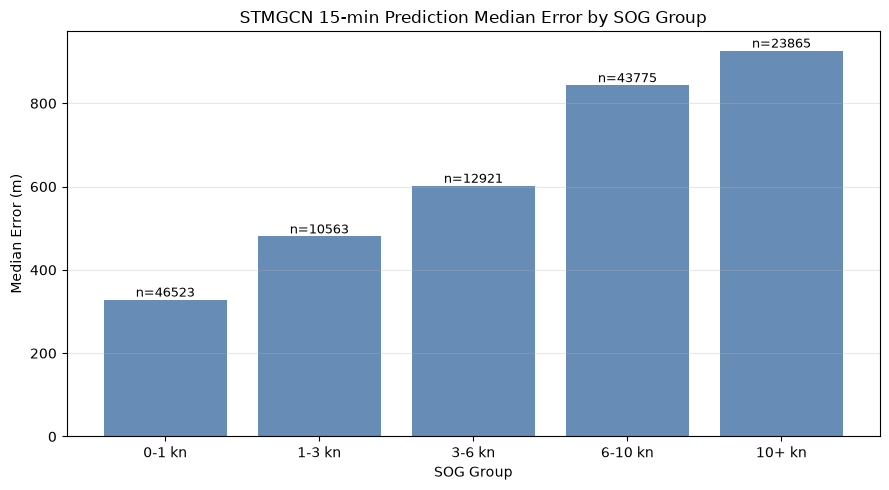

In [6]:
# STMGCN 15분 기준 SOG 그룹별 Median Error 막대그래프

STMGNN_SOG_HORIZON_SECONDS = 900  # 15분

stmgcn_sog_df = test_trajectory_results_df[
    test_trajectory_results_df["forecast_seconds"] == STMGNN_SOG_HORIZON_SECONDS
].copy()

if len(stmgcn_sog_df) == 0:
    raise ValueError("15분 forecast 결과가 없습니다.")

# SOG 그룹 설정
# 항구 선박 기준으로 저속 구간을 조금 세분화
sog_bins = [-0.1, 1, 3, 6, 10, 100]
sog_labels = [
    "0-1 kn",
    "1-3 kn",
    "3-6 kn",
    "6-10 kn",
    "10+ kn"
]

stmgcn_sog_df["sog_group"] = pd.cut(
    stmgcn_sog_df["start_sog"],
    bins=sog_bins,
    labels=sog_labels
)

sog_group_summary_df = (
    stmgcn_sog_df
    .groupby("sog_group", observed=False)
    .agg(
        count=("error_m", "count"),
        vessel_count=("MMSI", "nunique"),
        median_error_m=("error_m", "median"),
        mean_error_m=("error_m", "mean"),
        p90_error_m=("error_m", lambda x: np.percentile(x, 90))
    )
    .reset_index()
)

display(sog_group_summary_df)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    sog_group_summary_df["sog_group"].astype(str),
    sog_group_summary_df["median_error_m"],
    color="#4C78A8",
    alpha=0.85
)

plt.xlabel("SOG Group")
plt.ylabel("Median Error (m)")
plt.title("STMGCN 15-min Prediction Median Error by SOG Group")
plt.grid(axis="y", alpha=0.3)

# 막대 위에 count 표시
for bar, count in zip(bars, sog_group_summary_df["count"]):
    height = bar.get_height()

    if not np.isnan(height):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"n={count}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

Selected saved trajectory path
MMSI: 440128230
base_time: 2024-08-09 04:50:30
SEQ_LEN: 20
raw_seq shape: (20, 7)
distance graph shape: (20, 20)
interaction graph shape: (20, 20)

Distance Graph Matrix Preview


,0,1,2,3,4,5,6,7,8,9
0,1.000,0.718,0.510,0.364,0.259,0.195,0.137,0.097,0.070,0.049
1,0.718,1.000,0.711,0.507,0.361,0.272,0.191,0.135,0.097,0.069
2,0.510,0.711,1.000,0.714,0.508,0.383,0.269,0.190,0.137,0.096
3,0.364,0.507,0.714,1.000,0.711,0.536,0.376,0.267,0.191,0.135
4,0.259,0.361,0.508,0.711,1.000,0.755,0.529,0.375,0.269,0.190
5,0.195,0.272,0.383,0.536,0.755,1.000,0.701,0.497,0.357,0.252
6,0.137,0.191,0.269,0.376,0.529,0.701,1.000,0.709,0.508,0.359
7,0.097,0.135,0.190,0.267,0.375,0.497,0.709,1.000,0.717,0.506
8,0.070,0.097,0.137,0.191,0.269,0.357,0.508,0.717,1.000,0.706
9,0.049,0.069,0.096,0.135,0.190,0.252,0.359,0.506,0.706,1.000



Interaction Graph Matrix Preview


,0,1,2,3,4,5,6,7,8,9
0,0.064,0.245,0.003,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.000,0.198,0.577,0.007,0.003,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.114,0.235,0.376,0.003,0.000,0.000,0.000,0.000
3,0.000,0.000,0.000,0.044,0.064,0.131,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.000,0.248,0.758,0.010,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.000,0.141,0.540,0.007,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.000,0.268,1.000,0.601,0.010
7,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.174,0.148,0.641
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.164,0.913
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.248


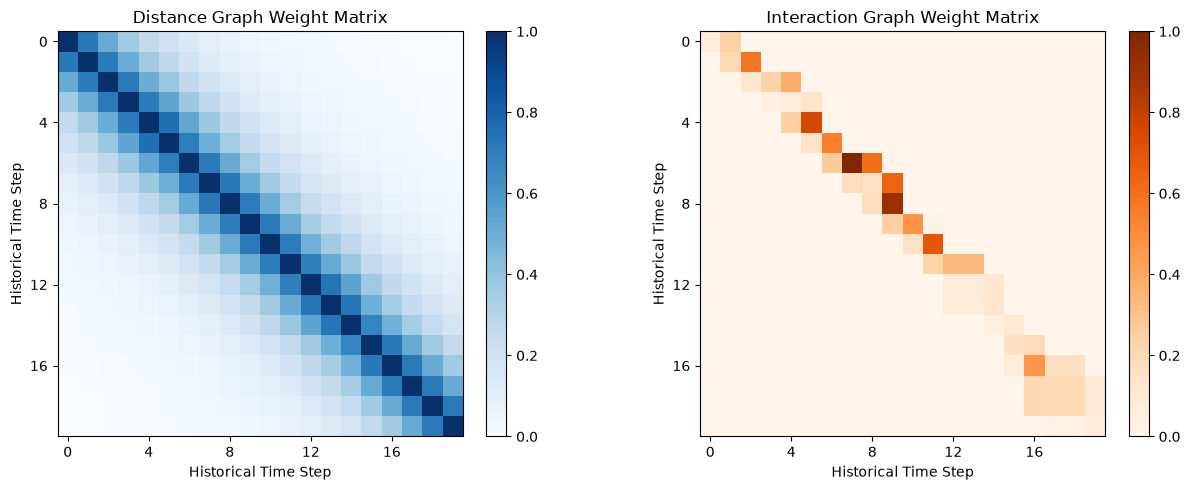

In [8]:
# Distance Graph / Interaction Graph 예시 행렬 출력 + heatmap
# test_items/test_raw 없이, 저장된 test_trajectory_paths의 raw_seq를 사용

GRAPH_PATH_INDEX = len(test_trajectory_paths) // 2

path_item = test_trajectory_paths[GRAPH_PATH_INDEX]

raw_seq = path_item["raw_seq"]
mmsi = path_item["MMSI"]
base_time = path_item["base_time"]

multi_graph = create_multi_graph(raw_seq)

distance_graph = multi_graph[0]
interaction_graph = multi_graph[1]

print("Selected saved trajectory path")
print("MMSI:", mmsi)
print("base_time:", base_time)
print("SEQ_LEN:", SEQ_LEN)
print("raw_seq shape:", raw_seq.shape)
print("distance graph shape:", distance_graph.shape)
print("interaction graph shape:", interaction_graph.shape)

distance_graph_df = pd.DataFrame(distance_graph)
interaction_graph_df = pd.DataFrame(interaction_graph)

print("\nDistance Graph Matrix Preview")
display(distance_graph_df.iloc[:10, :10].round(3))

print("\nInteraction Graph Matrix Preview")
display(interaction_graph_df.iloc[:10, :10].round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(distance_graph, cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Distance Graph Weight Matrix")
axes[0].set_xlabel("Historical Time Step")
axes[0].set_ylabel("Historical Time Step")

im1 = axes[1].imshow(interaction_graph, cmap="Oranges", vmin=0, vmax=1)
axes[1].set_title("Interaction Graph Weight Matrix")
axes[1].set_xlabel("Historical Time Step")
axes[1].set_ylabel("Historical Time Step")

for ax in axes:
    tick_step = max(1, SEQ_LEN // 5)
    ax.set_xticks(range(0, SEQ_LEN, tick_step))
    ax.set_yticks(range(0, SEQ_LEN, tick_step))

plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

5분 실제 이동거리 요약:


count    163607.000000
mean        868.113072
std         725.419708
min           0.003701
25%          17.880134
50%         998.098722
75%        1509.503854
max        2852.097107
Name: actual_move_5min_m, dtype: float64

horizon counts after moving filter:


,forecast_seconds,forecast_minutes,row_count,sample_count,vessel_count,median_error_m,mean_error_m
0,30,0.5,117445,117445,518,4.702583,6.856211
1,60,1.0,117425,117425,518,10.142853,13.615502
2,300,5.0,117488,117488,518,131.734728,173.184265
3,600,10.0,106830,106830,518,429.790489,538.432701
4,900,15.0,95340,95340,514,811.095294,996.208895


5분 실제 이동거리 50m 이상 기준 상위 5척


,mmsi,vessel_mean_error_m,vessel_median_error_m,vessel_p90_error_m,vessel_max_error_m,sample_count,row_count,mean_actual_move_5min_m,median_actual_move_5min_m,mean_start_sog
121,312200000,246.913287,12.264028,1098.490837,2038.506960,34,136,1419.288134,1448.143187,9.073529
344,538004065,254.965530,12.394347,1091.489140,1812.972400,20,80,1209.933683,1074.384438,7.568334
331,477735800,172.958294,15.505410,633.715454,1438.300005,26,104,867.540097,863.053851,5.725641
420,567582000,288.397024,15.710684,1214.832081,2042.094717,36,144,1343.878605,1356.918354,8.289815
353,538007592,243.350931,15.939642,777.562515,1753.736157,28,112,1616.396435,1625.085167,9.504762
191,371139000,236.654765,16.514732,1020.430061,1937.667033,47,188,1296.396861,1309.050143,7.643971


그래프에 사용할 대표 sample


,mmsi,sample_index,base_time,actual_move_5min_m,sample_mean_error_m,sample_median_error_m,sample_max_error_m,vessel_mean_error_m,vessel_median_error_m,vessel_p90_error_m,sample_count,mean_actual_move_5min_m,mean_start_sog
0,312200000.0,39215,2024-08-30 19:04:30,1347.524004,45.531319,3.300270,173.045157,246.913287,12.264028,1098.490837,34.0,1419.288134,9.073529
1,538004065.0,119756,2024-08-30 07:27:30,1083.770106,129.665565,8.062389,501.266761,254.965530,12.394347,1091.489140,20.0,1209.933683,7.568334
2,477735800.0,115680,2024-08-03 20:40:00,847.186727,150.637622,7.663063,584.583972,172.958294,15.505410,633.715454,26.0,867.540097,5.725641
3,567582000.0,145185,2024-08-07 05:45:00,1149.804158,173.863418,5.089037,682.844773,288.397024,15.710684,1214.832081,36.0,1343.878605,8.289815
4,538007592.0,122658,2024-08-24 18:09:30,1698.889781,155.948011,11.929537,592.653688,243.350931,15.939642,777.562515,28.0,1616.396435,9.504762
5,371139000.0,70452,2024-08-06 06:03:00,1543.755384,141.256304,11.218398,539.392037,236.654765,16.514732,1020.430061,47.0,1296.396861,7.643971


상위 5척 각 예측시점 거리오차 표


,rank,MMSI,horizon,error_m,actual_move_5min_m,base_time
0,1,312200000,30s,3.81,1347.52,2024-08-30 19:04:30
1,1,312200000,1min,2.48,1347.52,2024-08-30 19:04:30
2,1,312200000,5min,2.79,1347.52,2024-08-30 19:04:30
3,1,312200000,15min,173.05,1347.52,2024-08-30 19:04:30
4,2,538004065,30s,3.77,1083.77,2024-08-30 07:27:30
5,2,538004065,1min,1.27,1083.77,2024-08-30 07:27:30
6,2,538004065,5min,12.36,1083.77,2024-08-30 07:27:30
7,2,538004065,15min,501.27,1083.77,2024-08-30 07:27:30
8,3,477735800,30s,2.64,847.19,2024-08-03 20:40:00
9,3,477735800,1min,3.05,847.19,2024-08-03 20:40:00


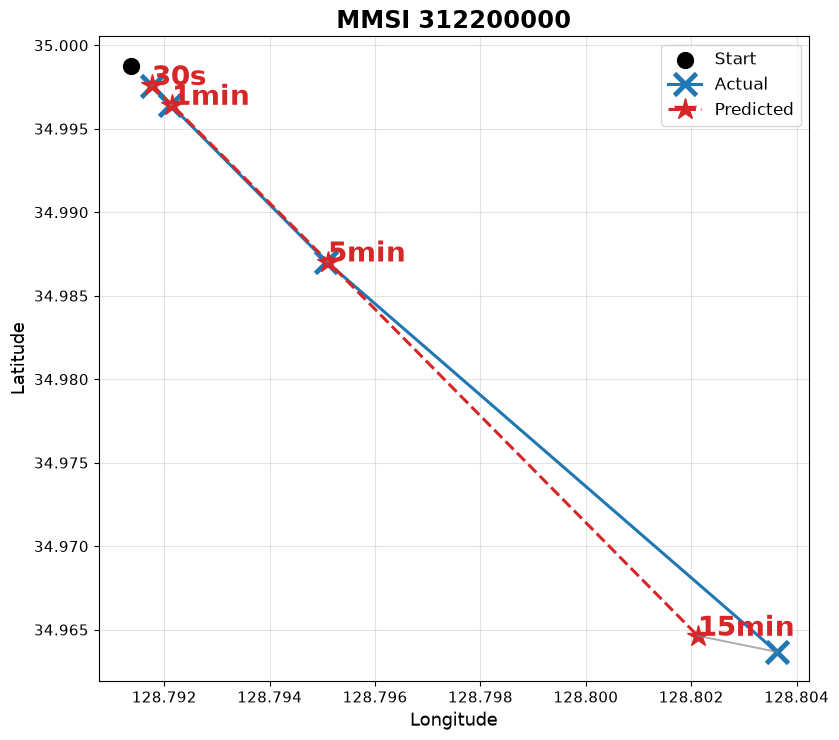

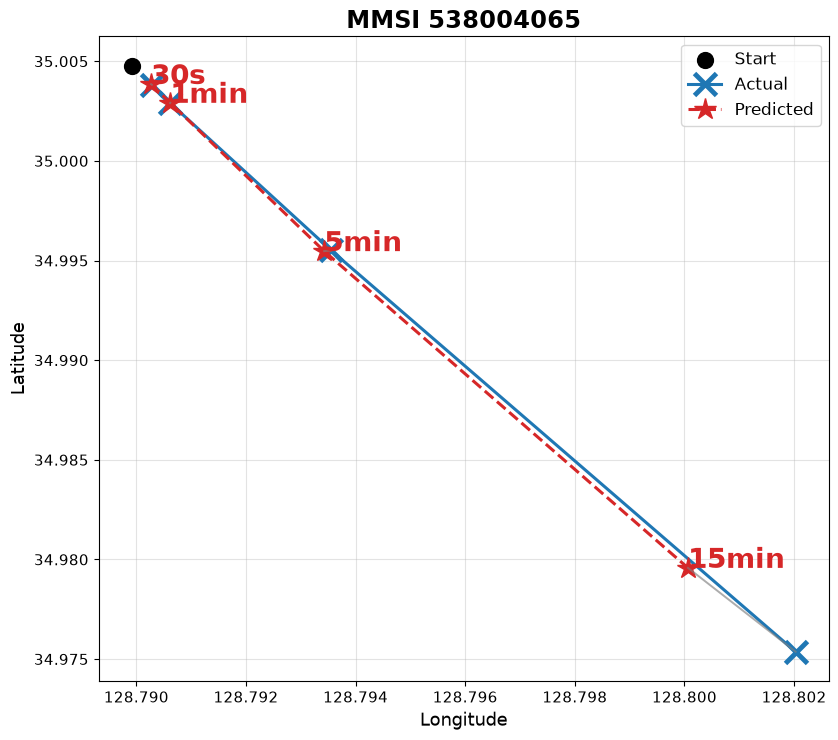

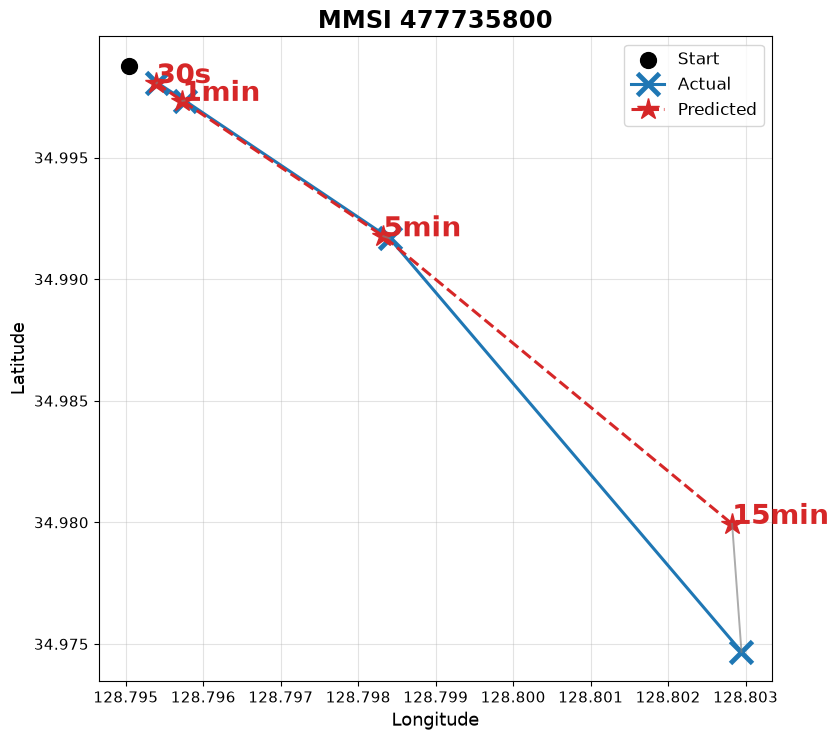

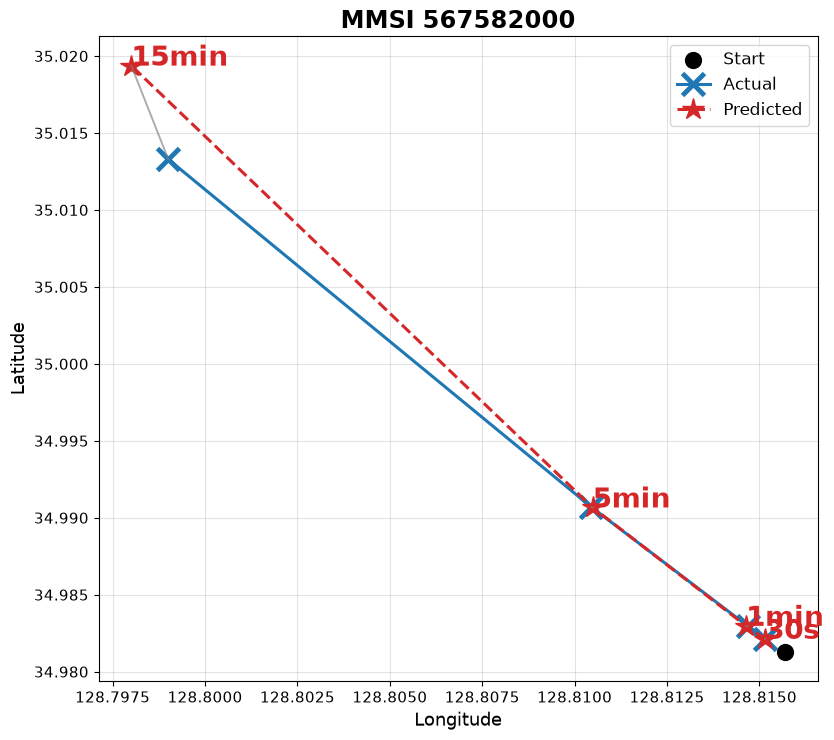

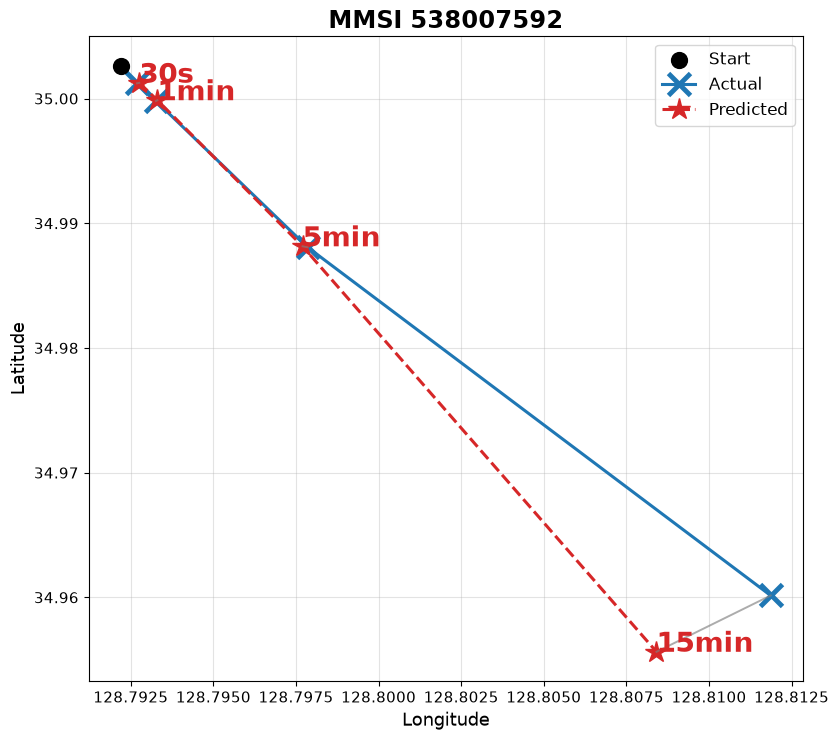

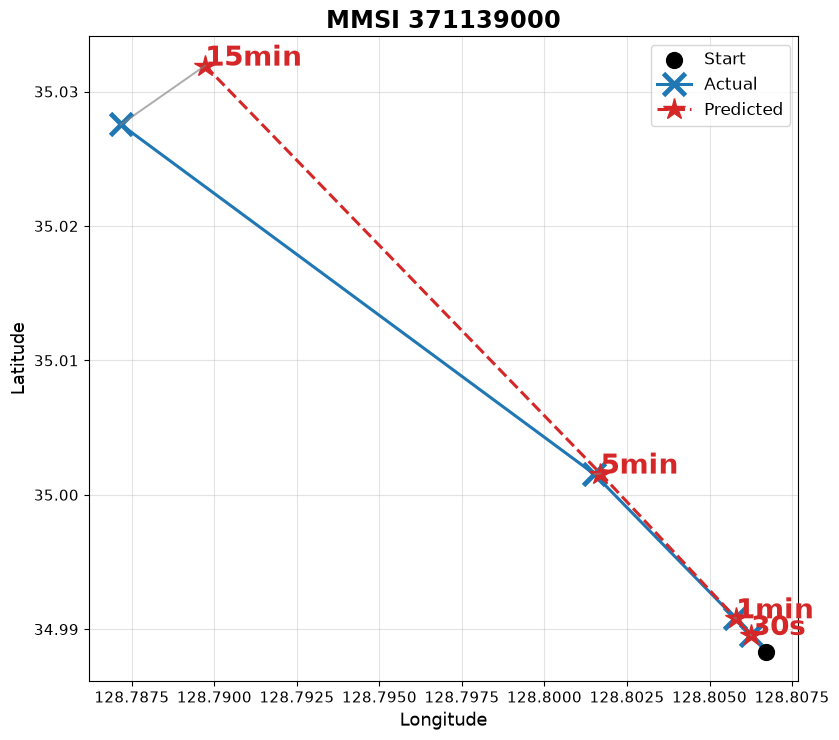

In [11]:
# 20. 실제 5분 이동거리 50m 이상 선박 기준 상위 5척 그래프
# 기준:
# - horizon: 30초, 1분, 5분
# - 5분 실제 이동거리 >= 50m인 sample만 사용
# - MMSI별 median error 기준 상위 5척
# - 선박 1척당 대표 sample 1개 그래프 출력
# - 예측-실제 연결선 포함
# - 그래프 제목은 MMSI만 표시
# - 선박별 각 예측시점 거리오차 표 출력

SHORT_SELECTION_SECONDS = [30, 60, 300, 900]
TOP_N = 6
MIN_SAMPLE_COUNT = 5
MIN_ACTUAL_MOVE_5MIN_M = 50
SCORE_COL = "vessel_median_error_m"


def build_plot_dataframe_moving(results_df, paths):
    result_df = results_df.copy().rename(columns={
        "MMSI": "mmsi",
        "actual_lat": "true_lat",
        "actual_lon": "true_lon"
    })

    start_rows = []

    for sample_index, item in enumerate(paths):
        start_rows.append({
            "sample_index": sample_index,
            "mmsi": item.get("MMSI"),
            "base_time": item.get("base_time"),
            "last_lat": item.get("start_lat"),
            "last_lon": item.get("start_lon"),
            "path_start_sog": item.get("start_sog", np.nan)
        })

    start_df = pd.DataFrame(start_rows)

    result_df = result_df.merge(
        start_df,
        on=["mmsi", "base_time"],
        how="inner",
        suffixes=("", "_path")
    )

    if "start_sog" not in result_df.columns:
        if "start_sog_x" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_x"]
        elif "start_sog_y" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_y"]
        elif "path_start_sog" in result_df.columns:
            result_df["start_sog"] = result_df["path_start_sog"]
        else:
            result_df["start_sog"] = np.nan

    if "path_start_sog" in result_df.columns:
        result_df["start_sog"] = result_df["start_sog"].fillna(result_df["path_start_sog"])

    return result_df.dropna(
        subset=[
            "sample_index",
            "mmsi",
            "base_time",
            "forecast_seconds",
            "pred_lat",
            "pred_lon",
            "true_lat",
            "true_lon",
            "error_m",
            "last_lat",
            "last_lon"
        ]
    )


def add_actual_move_distance_5min(plot_df):
    df = plot_df.copy()

    move_5min_df = df[df["forecast_seconds"] == 300].copy()

    move_5min_df["actual_move_5min_m"] = haversine_km(
        move_5min_df["last_lat"],
        move_5min_df["last_lon"],
        move_5min_df["true_lat"],
        move_5min_df["true_lon"]
    ) * 1000

    move_5min_df = move_5min_df[[
        "sample_index",
        "actual_move_5min_m"
    ]]

    df = df.merge(
        move_5min_df,
        on="sample_index",
        how="left"
    )

    return df


def select_top_vessels_moving_5min(plot_df):
    horizon_df = plot_df[
        plot_df["forecast_seconds"].isin(SHORT_SELECTION_SECONDS)
    ].copy()

    if len(horizon_df) == 0:
        raise ValueError("SHORT_SELECTION_SECONDS에 해당하는 결과가 없습니다.")

    horizon_df = horizon_df[
        horizon_df["actual_move_5min_m"] >= MIN_ACTUAL_MOVE_5MIN_M
    ].copy()

    if len(horizon_df) == 0:
        raise ValueError("5분 실제 이동거리 50m 이상인 sample이 없습니다.")

    sample_score_df = (
        horizon_df
        .groupby("sample_index")
        .agg(
            mmsi=("mmsi", "first"),
            base_time=("base_time", "first"),
            actual_move_5min_m=("actual_move_5min_m", "first"),
            sample_mean_error_m=("error_m", "mean"),
            sample_median_error_m=("error_m", "median"),
            sample_max_error_m=("error_m", "max"),
            sample_start_sog=("start_sog", "first"),
            horizon_count=("forecast_seconds", "nunique")
        )
        .reset_index()
    )

    valid_sample_df = sample_score_df[
        sample_score_df["horizon_count"] >= len(SHORT_SELECTION_SECONDS)
    ].copy()

    if len(valid_sample_df) == 0:
        raise ValueError("30초, 1분, 5분 horizon을 모두 가진 moving sample이 없습니다.")

    valid_horizon_df = horizon_df[
        horizon_df["sample_index"].isin(valid_sample_df["sample_index"])
    ].copy()

    vessel_score_df = (
        valid_horizon_df
        .groupby("mmsi")
        .agg(
            vessel_mean_error_m=("error_m", "mean"),
            vessel_median_error_m=("error_m", "median"),
            vessel_p90_error_m=("error_m", lambda x: np.percentile(x, 90)),
            vessel_max_error_m=("error_m", "max"),
            sample_count=("sample_index", "nunique"),
            row_count=("error_m", "count"),
            mean_actual_move_5min_m=("actual_move_5min_m", "mean"),
            median_actual_move_5min_m=("actual_move_5min_m", "median"),
            mean_start_sog=("start_sog", "mean")
        )
        .reset_index()
    )

    vessel_score_df = vessel_score_df[
        vessel_score_df["sample_count"] >= MIN_SAMPLE_COUNT
    ].copy()

    if len(vessel_score_df) == 0:
        print("주의: sample_count 조건을 만족하는 선박이 없습니다.")
        print("MIN_SAMPLE_COUNT 조건을 완화합니다.")

        vessel_score_df = (
            valid_horizon_df
            .groupby("mmsi")
            .agg(
                vessel_mean_error_m=("error_m", "mean"),
                vessel_median_error_m=("error_m", "median"),
                vessel_p90_error_m=("error_m", lambda x: np.percentile(x, 90)),
                vessel_max_error_m=("error_m", "max"),
                sample_count=("sample_index", "nunique"),
                row_count=("error_m", "count"),
                mean_actual_move_5min_m=("actual_move_5min_m", "mean"),
                median_actual_move_5min_m=("actual_move_5min_m", "median"),
                mean_start_sog=("start_sog", "mean")
            )
            .reset_index()
        )

    vessel_score_df = vessel_score_df.sort_values(SCORE_COL, ascending=True)
    top_vessels_df = vessel_score_df.head(TOP_N).copy()

    representative_rows = []

    for _, vessel_row in top_vessels_df.iterrows():
        mmsi = vessel_row["mmsi"]

        vessel_samples = valid_sample_df[
            valid_sample_df["mmsi"] == mmsi
        ].copy()

        vessel_samples = vessel_samples.sort_values(
            "sample_median_error_m",
            ascending=True
        )

        best_sample = vessel_samples.iloc[0]

        representative_rows.append({
            "mmsi": mmsi,
            "sample_index": best_sample["sample_index"],
            "base_time": best_sample["base_time"],
            "actual_move_5min_m": best_sample["actual_move_5min_m"],
            "sample_mean_error_m": best_sample["sample_mean_error_m"],
            "sample_median_error_m": best_sample["sample_median_error_m"],
            "sample_max_error_m": best_sample["sample_max_error_m"],
            "vessel_mean_error_m": vessel_row["vessel_mean_error_m"],
            "vessel_median_error_m": vessel_row["vessel_median_error_m"],
            "vessel_p90_error_m": vessel_row["vessel_p90_error_m"],
            "sample_count": vessel_row["sample_count"],
            "mean_actual_move_5min_m": vessel_row["mean_actual_move_5min_m"],
            "mean_start_sog": vessel_row["mean_start_sog"]
        })

    representative_df = pd.DataFrame(representative_rows)

    return vessel_score_df, top_vessels_df, representative_df


def make_vessel_horizon_error_table(plot_df, representative_df):
    rows = []

    for rank, (_, sample_row) in enumerate(representative_df.iterrows(), start=1):
        sample_index = sample_row["sample_index"]

        group = plot_df[
            (plot_df["sample_index"] == sample_index)
            & (plot_df["forecast_seconds"].isin(SHORT_SELECTION_SECONDS))
        ].copy()

        group = group.sort_values("forecast_seconds")

        for _, row in group.iterrows():
            if row["forecast_seconds"] < 60:
                horizon_label = f"{int(row['forecast_seconds'])}s"
            else:
                horizon_label = f"{row['forecast_minutes']:.0f}min"

            rows.append({
                "rank": rank,
                "MMSI": row["mmsi"],
                "base_time": row["base_time"],
                "horizon": horizon_label,
                "forecast_seconds": row["forecast_seconds"],
                "error_m": row["error_m"],
                "pred_lat": row["pred_lat"],
                "pred_lon": row["pred_lon"],
                "actual_lat": row["true_lat"],
                "actual_lon": row["true_lon"],
                "actual_move_5min_m": row["actual_move_5min_m"]
            })

    error_table_df = pd.DataFrame(rows)

    return error_table_df


def plot_single_top_vessel_moving_large(plot_df, sample_row, rank):
    sample_index = sample_row["sample_index"]

    group = plot_df[
        (plot_df["sample_index"] == sample_index)
        & (plot_df["forecast_seconds"].isin(SHORT_SELECTION_SECONDS))
    ].copy()

    group = group.sort_values("forecast_seconds")

    if len(group) == 0:
        return

    mmsi = group.iloc[0]["mmsi"]

    plt.figure(figsize=(8.5, 7.5))

    plt.scatter(
        group.iloc[0]["last_lon"],
        group.iloc[0]["last_lat"],
        color="black",
        marker="o",
        s=130,
        label="Start",
        zorder=5
    )

    plt.plot(
        group["true_lon"],
        group["true_lat"],
        color="tab:blue",
        linestyle="-",
        marker="x",
        linewidth=2.2,
        markersize=16,
        markeredgewidth=3.5,
        label="Actual"
    )

    plt.plot(
        group["pred_lon"],
        group["pred_lat"],
        color="tab:red",
        linestyle="--",
        marker="*",
        linewidth=2.2,
        markersize=16,
        label="Predicted"
    )

    for _, row in group.iterrows():
        plt.plot(
            [row["true_lon"], row["pred_lon"]],
            [row["true_lat"], row["pred_lat"]],
            color="gray",
            alpha=0.65,
            linewidth=1.4
        )

        if row["forecast_seconds"] < 60:
            label = f"{int(row['forecast_seconds'])}s"
        else:
            label = f"{row['forecast_minutes']:.0f}min"

        plt.text(
            row["pred_lon"],
            row["pred_lat"],
            label,
            fontsize=20,
            fontweight="bold",
            color="tab:red"
        )

    plt.title(f"MMSI {mmsi}", fontsize=17, fontweight="bold")
    plt.xlabel("Longitude", fontsize=13)
    plt.ylabel("Latitude", fontsize=13)
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=12)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")
    ax.tick_params(axis="both", labelsize=11)

    plt.tight_layout()
    plt.show()


plot_df_moving = build_plot_dataframe_moving(
    test_trajectory_results_df,
    test_trajectory_paths
)

plot_df_moving = add_actual_move_distance_5min(plot_df_moving)

print("5분 실제 이동거리 요약:")
display(
    plot_df_moving[plot_df_moving["forecast_seconds"] == 300]["actual_move_5min_m"]
    .describe()
)

print("horizon counts after moving filter:")
display(
    plot_df_moving[
        plot_df_moving["actual_move_5min_m"] >= MIN_ACTUAL_MOVE_5MIN_M
    ]
    .groupby("forecast_seconds")
    .agg(
        forecast_minutes=("forecast_minutes", "first"),
        row_count=("error_m", "count"),
        sample_count=("sample_index", "nunique"),
        vessel_count=("mmsi", "nunique"),
        median_error_m=("error_m", "median"),
        mean_error_m=("error_m", "mean")
    )
    .reset_index()
)

vessel_score_moving_df, top_vessels_moving_df, top5_representative_moving_df = select_top_vessels_moving_5min(
    plot_df_moving
)

print("5분 실제 이동거리 50m 이상 기준 상위 5척")
display(top_vessels_moving_df)

print("그래프에 사용할 대표 sample")
display(top5_representative_moving_df)

top5_horizon_error_table_df = make_vessel_horizon_error_table(
    plot_df_moving,
    top5_representative_moving_df
)

print("상위 5척 각 예측시점 거리오차 표")
display(
    top5_horizon_error_table_df[[
        "rank",
        "MMSI",
        "horizon",
        "error_m",
        "actual_move_5min_m",
        "base_time"
    ]].round({
        "error_m": 2,
        "actual_move_5min_m": 2
    })
)

for rank, (_, row) in enumerate(top5_representative_moving_df.iterrows(), start=1):
    plot_single_top_vessel_moving_large(plot_df_moving, row, rank)

15분 실제 이동거리 요약:


count    137647.000000
mean       2305.681869
std        2030.285155
min           0.003701
25%          12.743681
50%        2381.268718
75%        4216.168484
max        7903.900368
Name: actual_move_15min_m, dtype: float64

,sog_group,count,vessel_count,median_error_m,mean_error_m,p90_error_m,median_actual_move_15min_m
0,0-1 kn,3861,269,664.210028,1006.141971,2411.416048,612.898794
1,1-3 kn,10086,360,500.028393,944.423611,2401.195328,644.660874
2,3-6 kn,12912,396,601.984056,975.091422,2483.254075,1484.513593
3,6-10 kn,43775,496,843.487358,1012.045378,1919.985533,3971.030591
4,10+ kn,23865,452,926.484865,1035.061771,1835.782889,4582.165319


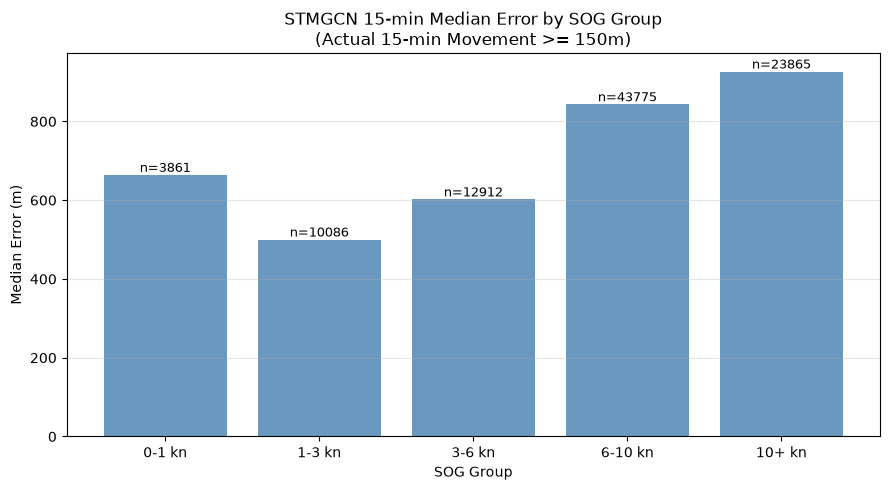

In [12]:
# STMGCN 15분 기준 SOG 그룹별 Median Error
# 실제 15분 누적 이동거리 150m 이상 sample만 사용

STMGNN_SOG_HORIZON_SECONDS = 900  # 15분
MIN_ACTUAL_MOVE_15MIN_M = 150

# 1. plot용 DataFrame 구성
def build_stmgcn_plot_dataframe_for_sog(results_df, paths):
    result_df = results_df.copy().rename(columns={
        "MMSI": "mmsi",
        "actual_lat": "true_lat",
        "actual_lon": "true_lon"
    })

    start_rows = []

    for sample_index, item in enumerate(paths):
        start_rows.append({
            "sample_index": sample_index,
            "mmsi": item.get("MMSI"),
            "base_time": item.get("base_time"),
            "last_lat": item.get("start_lat"),
            "last_lon": item.get("start_lon"),
            "path_start_sog": item.get("start_sog", np.nan)
        })

    start_df = pd.DataFrame(start_rows)

    result_df = result_df.merge(
        start_df,
        on=["mmsi", "base_time"],
        how="inner",
        suffixes=("", "_path")
    )

    if "start_sog" not in result_df.columns:
        if "start_sog_x" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_x"]
        elif "start_sog_y" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_y"]
        elif "path_start_sog" in result_df.columns:
            result_df["start_sog"] = result_df["path_start_sog"]
        else:
            result_df["start_sog"] = np.nan

    if "path_start_sog" in result_df.columns:
        result_df["start_sog"] = result_df["start_sog"].fillna(result_df["path_start_sog"])

    return result_df.dropna(
        subset=[
            "sample_index",
            "mmsi",
            "base_time",
            "forecast_seconds",
            "error_m",
            "last_lat",
            "last_lon",
            "true_lat",
            "true_lon",
            "start_sog"
        ]
    )


# 2. 15분 실제 이동거리 계산
def add_actual_move_15min_distance(plot_df):
    df = plot_df.copy()

    move_15min_df = df[df["forecast_seconds"] == STMGNN_SOG_HORIZON_SECONDS].copy()

    move_15min_df["actual_move_15min_m"] = haversine_km(
        move_15min_df["last_lat"],
        move_15min_df["last_lon"],
        move_15min_df["true_lat"],
        move_15min_df["true_lon"]
    ) * 1000

    move_15min_df = move_15min_df[[
        "sample_index",
        "actual_move_15min_m"
    ]]

    df = df.merge(
        move_15min_df,
        on="sample_index",
        how="left"
    )

    return df


stmgcn_sog_plot_df = build_stmgcn_plot_dataframe_for_sog(
    test_trajectory_results_df,
    test_trajectory_paths
)

stmgcn_sog_plot_df = add_actual_move_15min_distance(stmgcn_sog_plot_df)

print("15분 실제 이동거리 요약:")
display(
    stmgcn_sog_plot_df[
        stmgcn_sog_plot_df["forecast_seconds"] == STMGNN_SOG_HORIZON_SECONDS
    ]["actual_move_15min_m"].describe()
)

# 3. 15분 horizon + 실제 이동거리 150m 이상 필터
stmgcn_sog_filtered_df = stmgcn_sog_plot_df[
    (stmgcn_sog_plot_df["forecast_seconds"] == STMGNN_SOG_HORIZON_SECONDS)
    & (stmgcn_sog_plot_df["actual_move_15min_m"] >= MIN_ACTUAL_MOVE_15MIN_M)
].copy()

if len(stmgcn_sog_filtered_df) == 0:
    raise ValueError("15분 실제 이동거리 150m 이상인 sample이 없습니다.")

# 4. SOG 그룹 생성
sog_bins = [-0.1, 1, 3, 6, 10, 100]
sog_labels = [
    "0-1 kn",
    "1-3 kn",
    "3-6 kn",
    "6-10 kn",
    "10+ kn"
]

stmgcn_sog_filtered_df["sog_group"] = pd.cut(
    stmgcn_sog_filtered_df["start_sog"],
    bins=sog_bins,
    labels=sog_labels
)

# 5. SOG 그룹별 요약
sog_group_filtered_summary_df = (
    stmgcn_sog_filtered_df
    .groupby("sog_group", observed=False)
    .agg(
        count=("error_m", "count"),
        vessel_count=("mmsi", "nunique"),
        median_error_m=("error_m", "median"),
        mean_error_m=("error_m", "mean"),
        p90_error_m=("error_m", lambda x: np.percentile(x, 90)),
        median_actual_move_15min_m=("actual_move_15min_m", "median")
    )
    .reset_index()
)

display(sog_group_filtered_summary_df)

# 6. 막대그래프
plt.figure(figsize=(9, 5))

bars = plt.bar(
    sog_group_filtered_summary_df["sog_group"].astype(str),
    sog_group_filtered_summary_df["median_error_m"],
    color="#5B8DB8",
    alpha=0.9
)

plt.xlabel("SOG Group")
plt.ylabel("Median Error (m)")
plt.title("STMGCN 15-min Median Error by SOG Group\n(Actual 15-min Movement >= 150m)")
plt.grid(axis="y", alpha=0.3)

for bar, count in zip(bars, sog_group_filtered_summary_df["count"]):
    height = bar.get_height()

    if not np.isnan(height):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"n={count}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

,sog_group,count,vessel_count,median_error_m,mean_error_m,p90_error_m
0,0-1 kn,54982,357,2.652745,4.090061,8.885065
1,1-3 kn,13342,369,5.515011,7.106192,13.915761
2,3-6 kn,14086,400,4.291609,5.867447,11.675410
3,6-10 kn,50735,499,4.431613,6.621513,13.650060
4,10+ kn,42278,497,5.234970,8.461430,20.386053


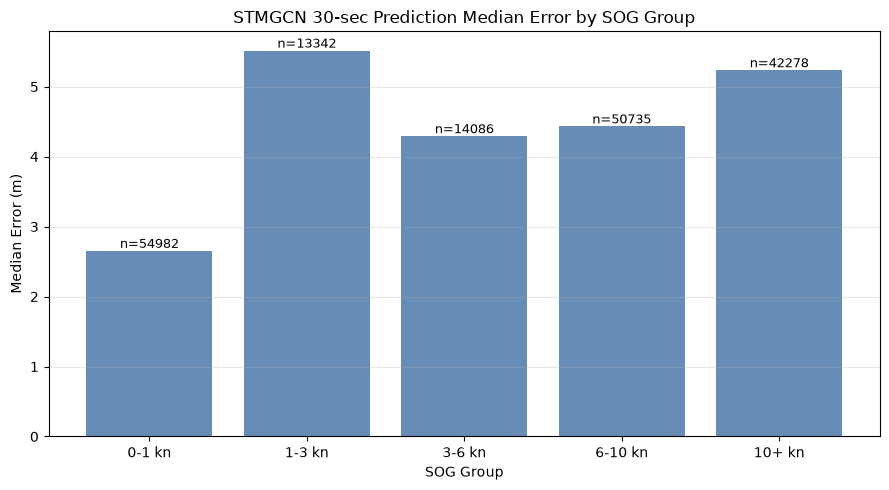

In [13]:
# STMGCN 30초 기준 SOG 그룹별 Median Error 막대그래프
# 실제 이동거리 필터 없음

STMGNN_SOG_HORIZON_SECONDS = 30  # 30초

stmgcn_sog_30s_df = test_trajectory_results_df[
    test_trajectory_results_df["forecast_seconds"] == STMGNN_SOG_HORIZON_SECONDS
].copy()

if len(stmgcn_sog_30s_df) == 0:
    raise ValueError("30초 forecast 결과가 없습니다.")

# SOG 그룹 설정
sog_bins = [-0.1, 1, 3, 6, 10, 100]
sog_labels = [
    "0-1 kn",
    "1-3 kn",
    "3-6 kn",
    "6-10 kn",
    "10+ kn"
]

stmgcn_sog_30s_df["sog_group"] = pd.cut(
    stmgcn_sog_30s_df["start_sog"],
    bins=sog_bins,
    labels=sog_labels
)

sog_group_30s_summary_df = (
    stmgcn_sog_30s_df
    .groupby("sog_group", observed=False)
    .agg(
        count=("error_m", "count"),
        vessel_count=("MMSI", "nunique"),
        median_error_m=("error_m", "median"),
        mean_error_m=("error_m", "mean"),
        p90_error_m=("error_m", lambda x: np.percentile(x, 90))
    )
    .reset_index()
)

display(sog_group_30s_summary_df)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    sog_group_30s_summary_df["sog_group"].astype(str),
    sog_group_30s_summary_df["median_error_m"],
    color="#4C78A8",
    alpha=0.85
)

plt.xlabel("SOG Group")
plt.ylabel("Median Error (m)")
plt.title("STMGCN 30-sec Prediction Median Error by SOG Group")
plt.grid(axis="y", alpha=0.3)

for bar, count in zip(bars, sog_group_30s_summary_df["count"]):
    height = bar.get_height()

    if not np.isnan(height):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"n={count}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

,forecast_seconds,forecast_minutes,sog_state,count,vessel_count,median_error_m,mean_error_m,p90_error_m
0,30,0.5,Stationary\n(≤0.5 kn),50247,350,2.471495,3.867214,8.227648
1,30,0.5,Low-speed\n(0.5-1.0 kn),4735,357,5.520768,6.454877,12.066886
2,30,0.5,Moving\n(>1.0 kn),120441,520,4.787888,7.232873,15.098173
3,60,1.0,Stationary\n(≤0.5 kn),49788,349,4.426148,6.192851,13.193025
4,60,1.0,Low-speed\n(0.5-1.0 kn),4726,357,11.642466,13.911295,26.620539
5,60,1.0,Moving\n(>1.0 kn),119496,520,10.277475,14.008197,28.492408


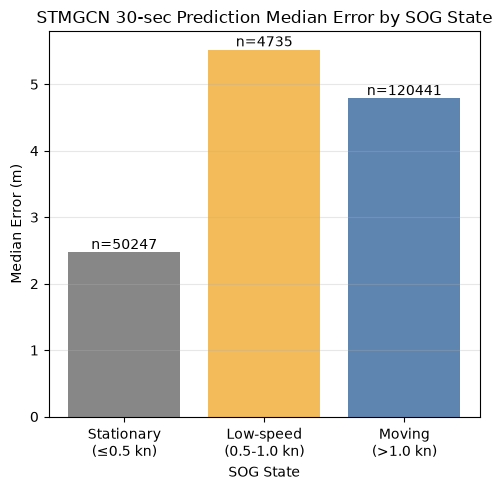

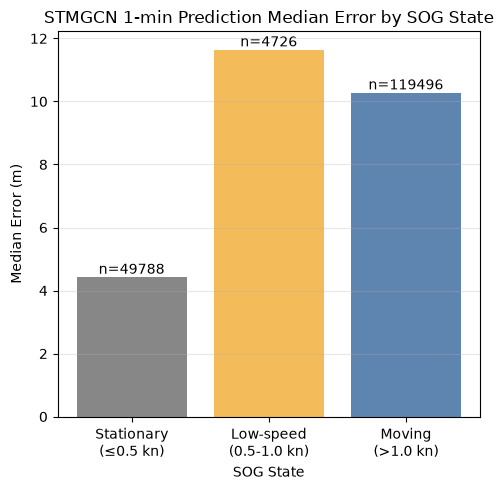

In [16]:
# STMGCN 30초 / 1분 기준 SOG 3분류별 Median Error
# SOG 기준:
# - Stationary: <= 0.5 kn
# - Low-speed/Berthing: 0.5~1.0 kn
# - Moving/Navigation: > 1.0 kn

SOG_STATE_BINS = [-0.1, 0.5, 1.0, 100]
SOG_STATE_LABELS = [
    "Stationary\n(≤0.5 kn)",
    "Low-speed\n(0.5-1.0 kn)",
    "Moving\n(>1.0 kn)"
]

TARGET_HORIZONS = [30, 60]


stmgcn_sog_state_df = test_trajectory_results_df[
    test_trajectory_results_df["forecast_seconds"].isin(TARGET_HORIZONS)
].copy()

if len(stmgcn_sog_state_df) == 0:
    raise ValueError("30초 또는 1분 forecast 결과가 없습니다.")

stmgcn_sog_state_df["sog_state"] = pd.cut(
    stmgcn_sog_state_df["start_sog"],
    bins=SOG_STATE_BINS,
    labels=SOG_STATE_LABELS
)

sog_state_summary_df = (
    stmgcn_sog_state_df
    .groupby(["forecast_seconds", "forecast_minutes", "sog_state"], observed=False)
    .agg(
        count=("error_m", "count"),
        vessel_count=("MMSI", "nunique"),
        median_error_m=("error_m", "median"),
        mean_error_m=("error_m", "mean"),
        p90_error_m=("error_m", lambda x: np.percentile(x, 90))
    )
    .reset_index()
)

display(sog_state_summary_df)

# 30초 / 1분 그래프 각각 출력
for horizon in TARGET_HORIZONS:
    plot_df = sog_state_summary_df[
        sog_state_summary_df["forecast_seconds"] == horizon
    ].copy()

    horizon_label = "30-sec" if horizon == 30 else "1-min"

    plt.figure(figsize=(5, 5))

    bars = plt.bar(
        plot_df["sog_state"].astype(str),
        plot_df["median_error_m"],
        color=["#7A7A7A", "#F2B447", "#4C78A8"],
        alpha=0.9
    )

    plt.xlabel("SOG State")
    plt.ylabel("Median Error (m)")
    plt.title(f"STMGCN {horizon_label} Prediction Median Error by SOG State")
    plt.grid(axis="y", alpha=0.3)

    for bar, count in zip(bars, plot_df["count"]):
        height = bar.get_height()

        if not np.isnan(height):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"n={count}",
                ha="center",
                va="bottom",
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

,sog_state,count,vessel_count,median_error_m,mean_error_m,p90_error_m
0,Stationary\n(≤0.5 kn),43309,349,326.824429,320.307076,428.535930
1,Low-speed\n(0.5-1.0 kn),3214,341,429.544512,853.925970,2264.982975
2,Moving\n(>1.0 kn),91124,514,822.470322,1002.080042,1985.849174


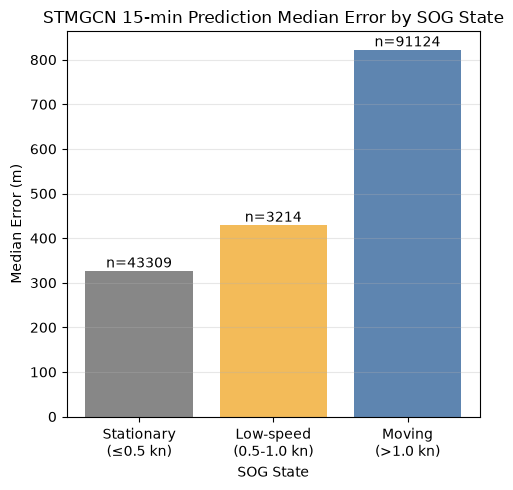

In [18]:
# STMGCN 15분 기준 SOG 3분류별 Median Error
# SOG 기준:
# - Stationary: <= 0.5 kn
# - Low-speed/Berthing: 0.5~1.0 kn
# - Moving/Navigation: > 1.0 kn

SOG_STATE_BINS = [-0.1, 0.5, 1.0, 100]
SOG_STATE_LABELS = [
    "Stationary\n(≤0.5 kn)",
    "Low-speed\n(0.5-1.0 kn)",
    "Moving\n(>1.0 kn)"
]

TARGET_HORIZON = 900  # 15분

stmgcn_sog_state_15min_df = test_trajectory_results_df[
    test_trajectory_results_df["forecast_seconds"] == TARGET_HORIZON
].copy()

if len(stmgcn_sog_state_15min_df) == 0:
    raise ValueError("15분 forecast 결과가 없습니다.")

stmgcn_sog_state_15min_df["sog_state"] = pd.cut(
    stmgcn_sog_state_15min_df["start_sog"],
    bins=SOG_STATE_BINS,
    labels=SOG_STATE_LABELS
)

sog_state_15min_summary_df = (
    stmgcn_sog_state_15min_df
    .groupby("sog_state", observed=False)
    .agg(
        count=("error_m", "count"),
        vessel_count=("MMSI", "nunique"),
        median_error_m=("error_m", "median"),
        mean_error_m=("error_m", "mean"),
        p90_error_m=("error_m", lambda x: np.percentile(x, 90))
    )
    .reset_index()
)

display(sog_state_15min_summary_df)

plt.figure(figsize=(5, 5))

bars = plt.bar(
    sog_state_15min_summary_df["sog_state"].astype(str),
    sog_state_15min_summary_df["median_error_m"],
    color=["#7A7A7A", "#F2B447", "#4C78A8"],
    alpha=0.9
)

plt.xlabel("SOG State")
plt.ylabel("Median Error (m)")
plt.title("STMGCN 15-min Prediction Median Error by SOG State")
plt.grid(axis="y", alpha=0.3)

for bar, count in zip(bars, sog_state_15min_summary_df["count"]):
    height = bar.get_height()

    if not np.isnan(height):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"n={count}",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.tight_layout()
plt.show()

15분까지 예측 가능한 sample 중 30초 오차 기준 상위 10척


,rank,mmsi,base_time,start_sog,forecast_seconds,forecast_minutes,error_m,pred_lat,pred_lon,true_lat,true_lon
0,1,352001646,2024-08-22 23:13:30,7.60,30,0.5,0.01,35.004398,128.805298,35.004398,128.805298
1,2,368680000,2024-08-03 08:39:00,0.00,30,0.5,0.01,35.069016,128.817352,35.069016,128.817352
2,3,273298570,2024-08-07 11:37:30,0.00,30,0.5,0.02,35.070316,128.825867,35.070316,128.825867
3,4,538003886,2024-08-20 04:55:00,9.53,30,0.5,0.02,35.025650,128.784836,35.025650,128.784836
4,5,636092984,2024-08-30 22:01:00,8.00,30,0.5,0.03,35.019661,128.796463,35.019661,128.796463
5,6,248411000,2024-08-16 15:29:00,0.00,30,0.5,0.03,35.068867,128.816757,35.068867,128.816758
6,7,355906000,2024-08-21 01:13:00,0.00,30,0.5,0.03,35.077286,128.805511,35.077286,128.805512
7,8,477681800,2024-08-25 20:27:00,0.00,30,0.5,0.03,35.066536,128.803146,35.066536,128.803147
8,9,477286300,2024-08-12 18:40:00,0.10,30,0.5,0.03,35.067665,128.808655,35.067665,128.808654
9,10,352870000,2024-08-24 01:59:00,0.00,30,0.5,0.04,35.077484,128.829269,35.077484,128.829269


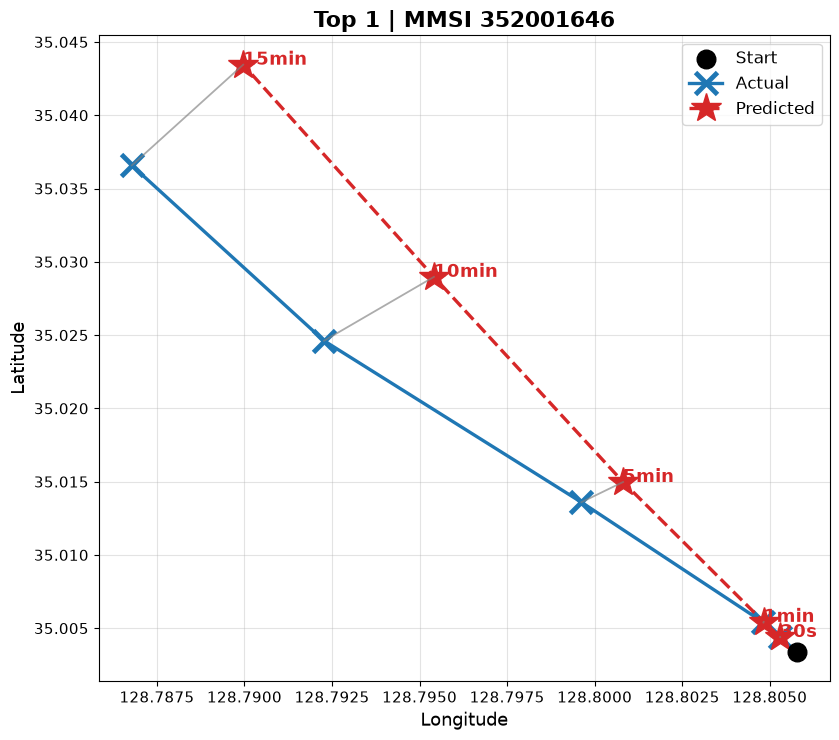

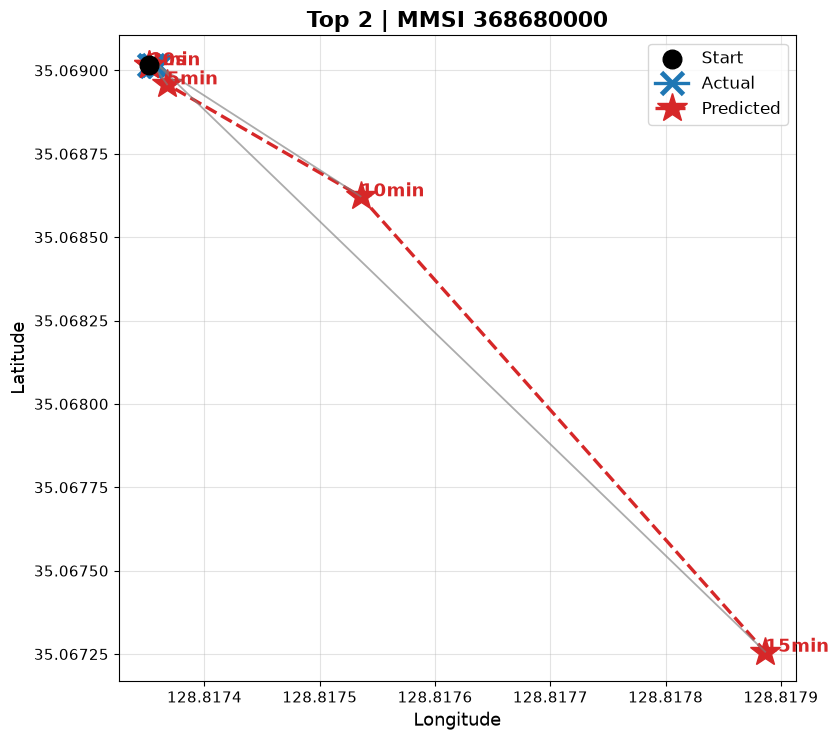

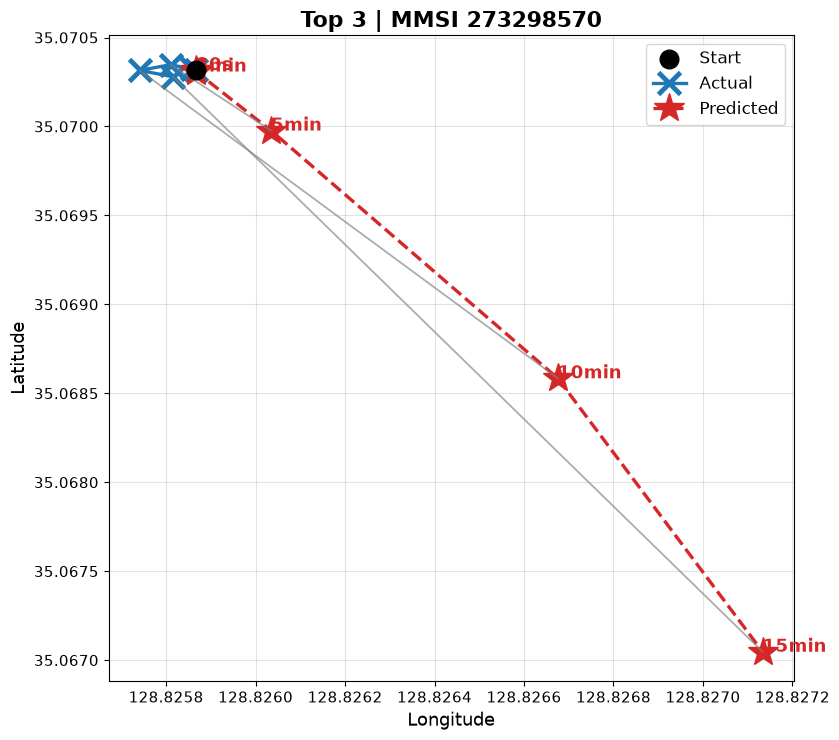

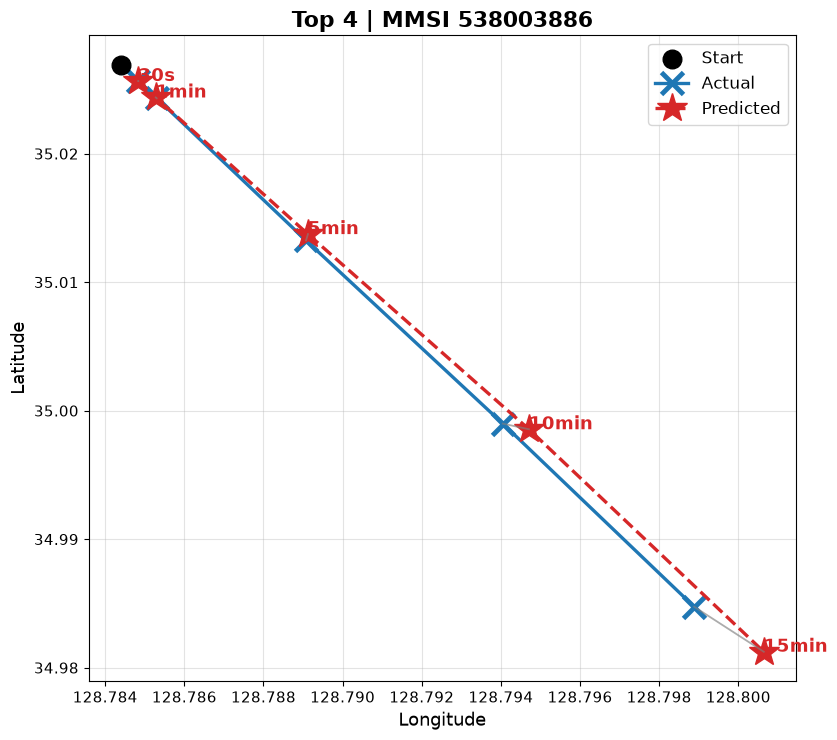

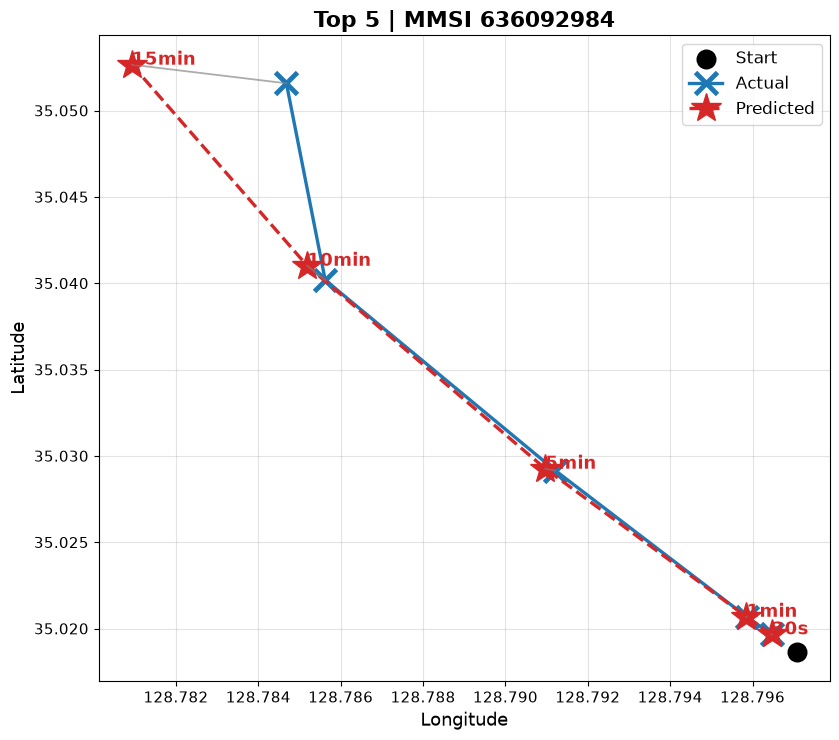

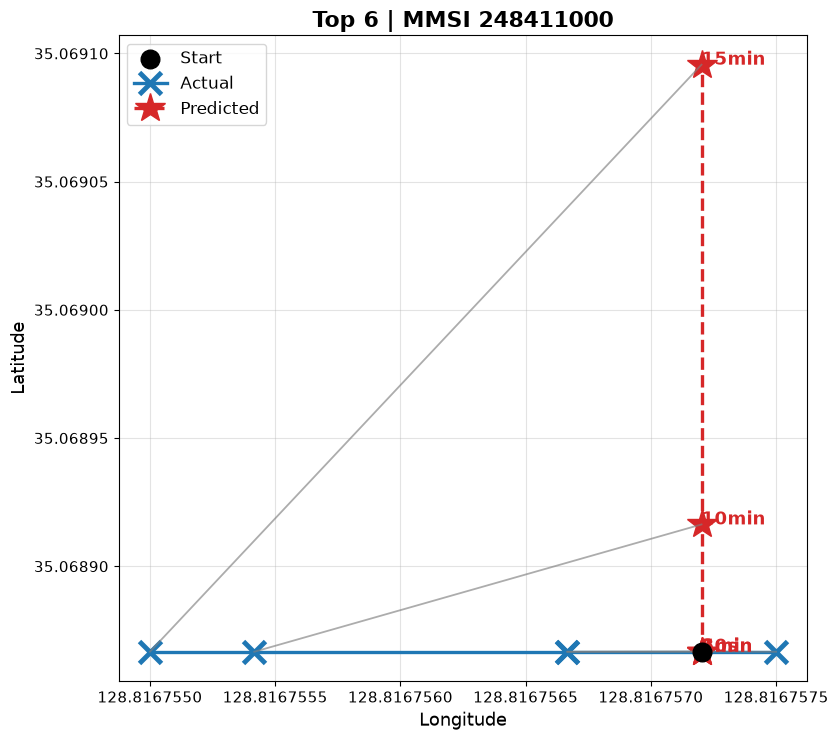

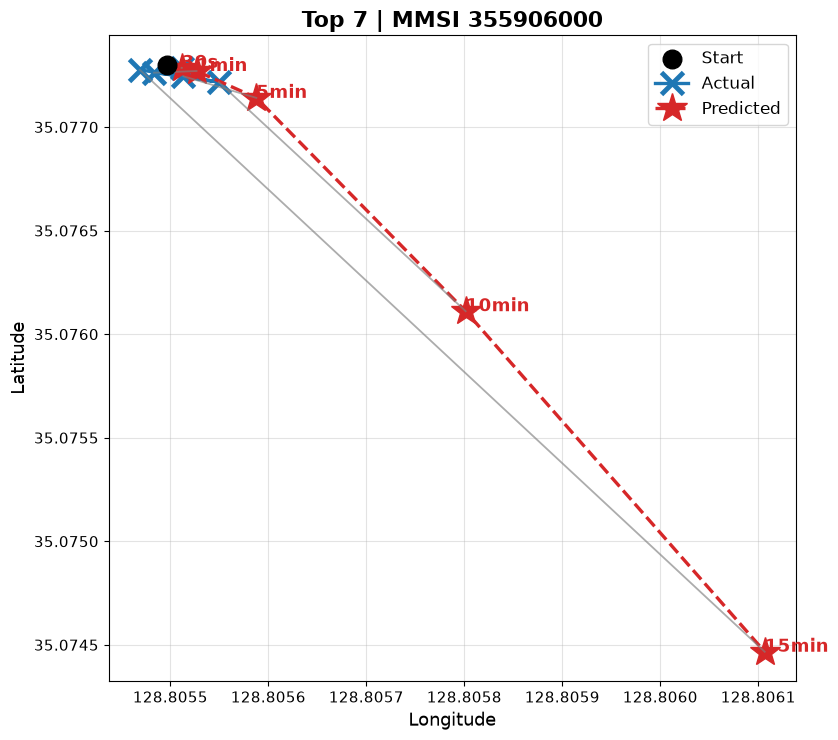

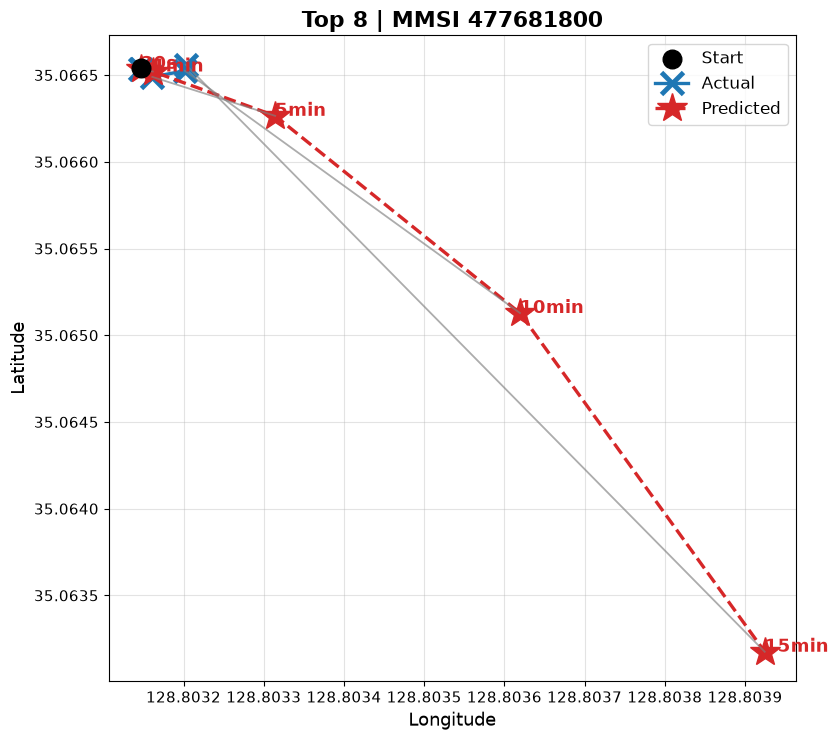

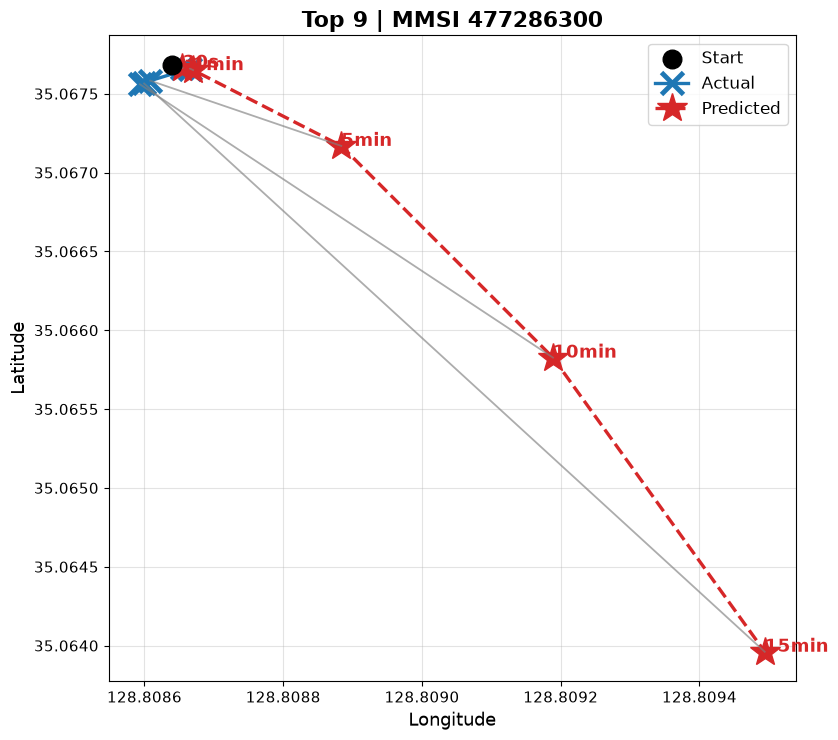

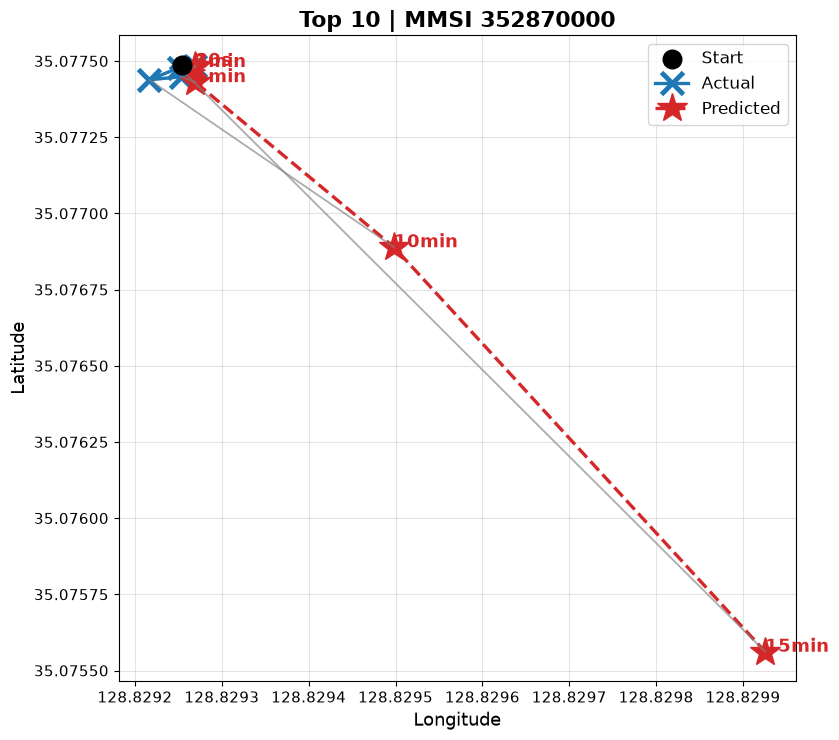

In [20]:
# 15분까지 예측 가능한 sample 중
# 30초 오차가 가장 작은 선박 상위 10척 표 + 그래프 출력

TOP_N = 10
SHORT_HORIZON_SECONDS = 30
FINAL_HORIZON_SECONDS = 900
PLOT_HORIZONS = [30, 60, 300, 600, 900]


def build_plot_df_from_results_and_paths(results_df, paths):
    result_df = results_df.copy().rename(columns={
        "MMSI": "mmsi",
        "actual_lat": "true_lat",
        "actual_lon": "true_lon"
    })

    start_rows = []

    for sample_index, item in enumerate(paths):
        start_rows.append({
            "sample_index": sample_index,
            "mmsi": item.get("MMSI"),
            "base_time": item.get("base_time"),
            "last_lat": item.get("start_lat"),
            "last_lon": item.get("start_lon"),
            "path_start_sog": item.get("start_sog", np.nan)
        })

    start_df = pd.DataFrame(start_rows)

    result_df = result_df.merge(
        start_df,
        on=["mmsi", "base_time"],
        how="inner",
        suffixes=("", "_path")
    )

    if "start_sog" not in result_df.columns:
        if "start_sog_x" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_x"]
        elif "start_sog_y" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_y"]
        elif "path_start_sog" in result_df.columns:
            result_df["start_sog"] = result_df["path_start_sog"]
        else:
            result_df["start_sog"] = np.nan

    if "path_start_sog" in result_df.columns:
        result_df["start_sog"] = result_df["start_sog"].fillna(result_df["path_start_sog"])

    return result_df.dropna(
        subset=[
            "mmsi",
            "base_time",
            "forecast_seconds",
            "pred_lat",
            "pred_lon",
            "true_lat",
            "true_lon",
            "error_m",
            "last_lat",
            "last_lon"
        ]
    )


plot_df_15min = build_plot_df_from_results_and_paths(
    test_trajectory_results_df,
    test_trajectory_paths
)


# 1. 15분까지 예측 가능한 sample 확인
sample_horizon_df = (
    plot_df_15min
    .groupby(["mmsi", "base_time"])
    .agg(
        horizon_count=("forecast_seconds", "nunique"),
        max_horizon=("forecast_seconds", "max")
    )
    .reset_index()
)

valid_15min_samples = sample_horizon_df[
    sample_horizon_df["max_horizon"] >= FINAL_HORIZON_SECONDS
].copy()


# 2. 15분까지 예측 가능한 sample 중 30초 결과만 추출
top30_candidate_df = plot_df_15min.merge(
    valid_15min_samples[["mmsi", "base_time"]],
    on=["mmsi", "base_time"],
    how="inner"
)

top30_candidate_df = top30_candidate_df[
    top30_candidate_df["forecast_seconds"] == SHORT_HORIZON_SECONDS
].copy()

if len(top30_candidate_df) == 0:
    raise ValueError("15분까지 예측 가능하면서 30초 결과가 있는 sample이 없습니다.")


# 3. 선박별 30초 오차가 가장 작은 대표 sample 선택
vessel_best_30s_df = (
    top30_candidate_df
    .sort_values("error_m", ascending=True)
    .groupby("mmsi", as_index=False)
    .first()
)

top10_vessels_by_30s_error_df = (
    vessel_best_30s_df
    .sort_values("error_m", ascending=True)
    .head(TOP_N)
    .reset_index(drop=True)
)

top10_vessels_by_30s_error_df["rank"] = np.arange(
    1,
    len(top10_vessels_by_30s_error_df) + 1
)


# 4. 상위 10척 표 출력
print("15분까지 예측 가능한 sample 중 30초 오차 기준 상위 10척")
display(
    top10_vessels_by_30s_error_df[[
        "rank",
        "mmsi",
        "base_time",
        "start_sog",
        "forecast_seconds",
        "forecast_minutes",
        "error_m",
        "pred_lat",
        "pred_lon",
        "true_lat",
        "true_lon"
    ]].round({
        "start_sog": 2,
        "error_m": 2,
        "pred_lat": 6,
        "pred_lon": 6,
        "true_lat": 6,
        "true_lon": 6
    })
)


# 5. 각 선박 그래프 함수
def plot_top_vessel_by_30s_error(plot_df, selected_row):
    mmsi = selected_row["mmsi"]
    base_time = selected_row["base_time"]
    rank = selected_row["rank"]

    group = plot_df[
        (plot_df["mmsi"] == mmsi)
        & (plot_df["base_time"] == base_time)
        & (plot_df["forecast_seconds"].isin(PLOT_HORIZONS))
    ].copy()

    group = group.sort_values("forecast_seconds")

    if len(group) == 0:
        return

    plt.figure(figsize=(8.5, 7.5))

    plt.scatter(
        group.iloc[0]["last_lon"],
        group.iloc[0]["last_lat"],
        color="black",
        marker="o",
        s=180,
        label="Start",
        zorder=5
    )

    plt.plot(
        group["true_lon"],
        group["true_lat"],
        color="tab:blue",
        linestyle="-",
        marker="x",
        linewidth=2.4,
        markersize=16,
        markeredgewidth=3.5,
        label="Actual"
    )

    plt.plot(
        group["pred_lon"],
        group["pred_lat"],
        color="tab:red",
        linestyle="--",
        marker="*",
        linewidth=2.4,
        markersize=22,
        label="Predicted"
    )

    for _, row in group.iterrows():
        plt.plot(
            [row["true_lon"], row["pred_lon"]],
            [row["true_lat"], row["pred_lat"]],
            color="gray",
            alpha=0.65,
            linewidth=1.3
        )

        if row["forecast_seconds"] < 60:
            label = f"{int(row['forecast_seconds'])}s"
        else:
            label = f"{row['forecast_minutes']:.0f}min"

        plt.text(
            row["pred_lon"],
            row["pred_lat"],
            label,
            fontsize=13,
            fontweight="bold",
            color="tab:red"
        )

    plt.title(f"Top {rank} | MMSI {mmsi}", fontsize=16, fontweight="bold")
    plt.xlabel("Longitude", fontsize=13)
    plt.ylabel("Latitude", fontsize=13)
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=12)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")
    ax.tick_params(axis="both", labelsize=11)

    plt.tight_layout()
    plt.show()


# 6. 그래프 10개 출력
for _, row in top10_vessels_by_30s_error_df.iterrows():
    plot_top_vessel_by_30s_error(plot_df_15min, row)

조건: 15분 예측 가능 + 실제 15분 이동거리 >= 150m
정렬: 선박별 전체 평균오차 작은 순 + 30초 오차 작은 순


,rank,mmsi,vessel_mean_error_m,vessel_median_error_m,vessel_best_30s_error_m,vessel_mean_30s_error_m,sample_count,mean_actual_move_15min_m,mean_start_sog
208,1,374353000,137.19,117.58,3.75,5.48,6,5059.43,9.31
199,2,372770000,137.28,41.10,0.40,2.75,5,4916.17,10.77
83,3,257672000,169.15,79.26,1.52,3.16,13,4946.13,8.88
50,4,232043367,181.79,73.95,0.18,3.32,118,2597.86,6.44
331,5,477735800,188.78,71.64,1.19,4.26,26,2865.26,5.73
264,6,440288000,196.17,98.13,0.16,3.84,199,2722.69,6.36
81,7,256940000,196.66,92.56,0.67,5.96,149,3294.92,7.97
425,8,636013522,198.21,61.68,0.52,5.42,60,4226.89,8.84
407,9,565819000,199.27,77.03,0.25,4.36,172,3017.56,7.14
126,10,312498000,204.90,82.70,0.14,2.78,40,4044.72,7.89


그래프에 사용할 대표 sample


C:\Users\HP\AppData\Local\Temp\ipykernel_27420\4038613893.py:259: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ]].round(2)


,rank,mmsi,base_time,sample_mean_error_m,sample_30s_error_m,sample_median_error_m,sample_max_error_m,actual_move_15min_m,start_sog
0,1.0,374353000.0,2024-08-03 17:32:00,71.40,6.60,67.02,158.89,5138.61,9.90
1,2.0,372770000.0,2024-08-17 16:22:00,108.67,3.26,41.10,433.53,4949.81,10.70
2,3.0,257672000.0,2024-08-26 21:37:00,77.43,2.14,48.29,229.50,4685.45,8.77
3,4.0,232043367.0,2024-08-30 15:36:30,36.33,5.13,35.33,92.55,3584.58,6.07
4,5.0,477735800.0,2024-08-03 20:36:30,65.11,3.70,71.80,148.36,2624.55,5.90
5,6.0,440288000.0,2024-08-18 12:44:00,25.98,0.92,24.87,56.28,3834.94,8.03
6,7.0,256940000.0,2024-08-11 11:13:00,42.81,1.27,27.13,121.11,553.04,1.90
7,8.0,636013522.0,2024-08-01 18:46:00,59.81,2.43,36.07,176.04,4159.57,9.13
8,9.0,565819000.0,2024-08-05 05:48:00,17.15,3.21,7.85,55.89,4114.07,8.27
9,10.0,312498000.0,2024-08-24 05:18:30,61.55,2.06,62.95,154.13,4148.91,7.70


상위 10척 대표 sample의 예측시점별 거리오차


,rank,MMSI,horizon,error_m,actual_move_15min_m,base_time
0,1.0,374353000.0,30s,6.60,5138.61,2024-08-03 17:32:00
1,1.0,374353000.0,1min,12.73,5138.61,2024-08-03 17:32:00
2,1.0,374353000.0,5min,67.02,5138.61,2024-08-03 17:32:00
3,1.0,374353000.0,10min,111.75,5138.61,2024-08-03 17:32:00
4,1.0,374353000.0,15min,158.89,5138.61,2024-08-03 17:32:00
5,2.0,372770000.0,30s,3.26,4949.81,2024-08-17 16:22:00
6,2.0,372770000.0,1min,4.16,4949.81,2024-08-17 16:22:00
7,2.0,372770000.0,5min,41.10,4949.81,2024-08-17 16:22:00
8,2.0,372770000.0,10min,61.31,4949.81,2024-08-17 16:22:00
9,2.0,372770000.0,15min,433.53,4949.81,2024-08-17 16:22:00


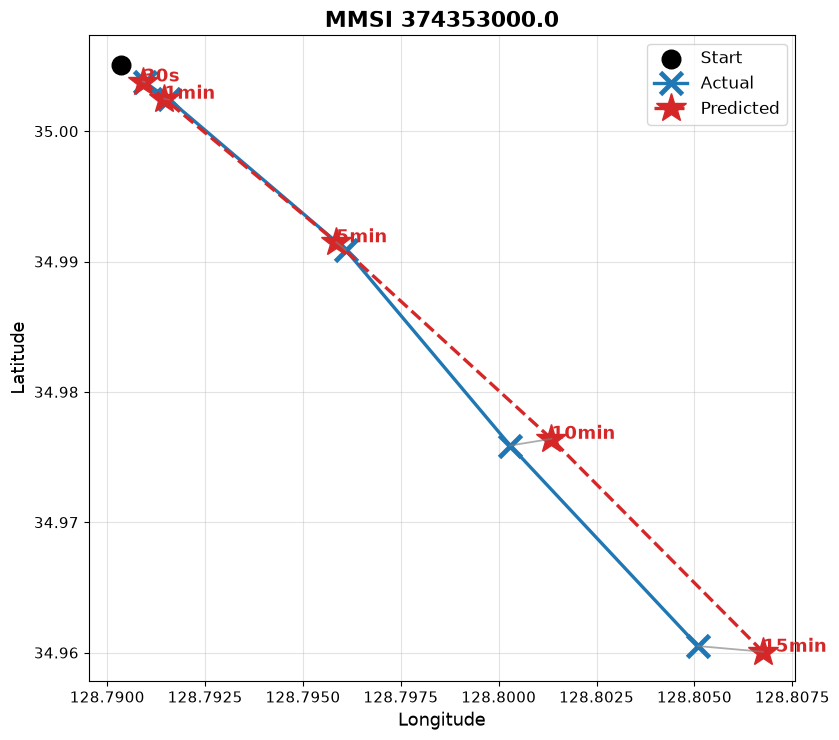

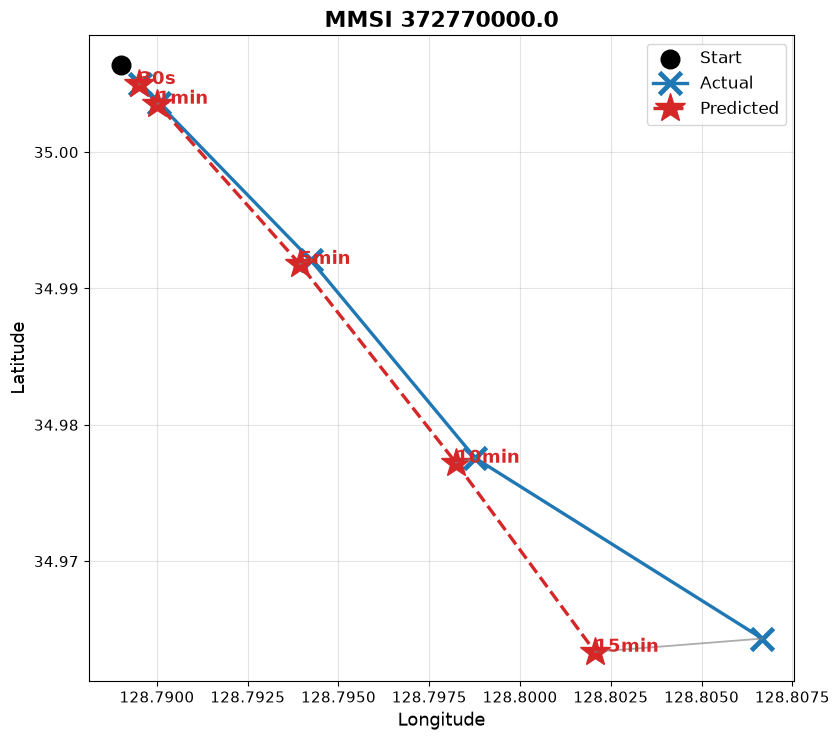

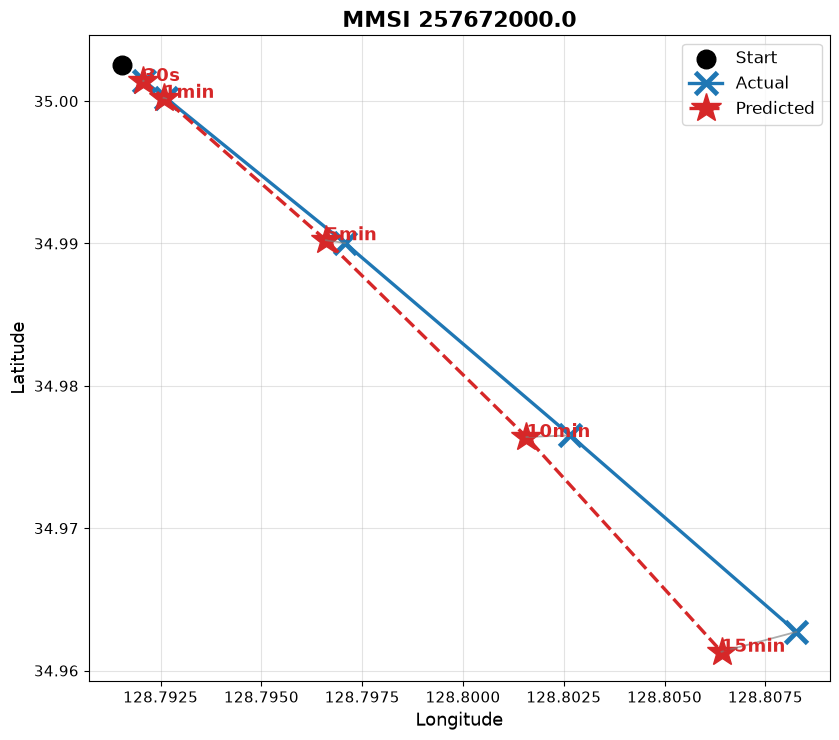

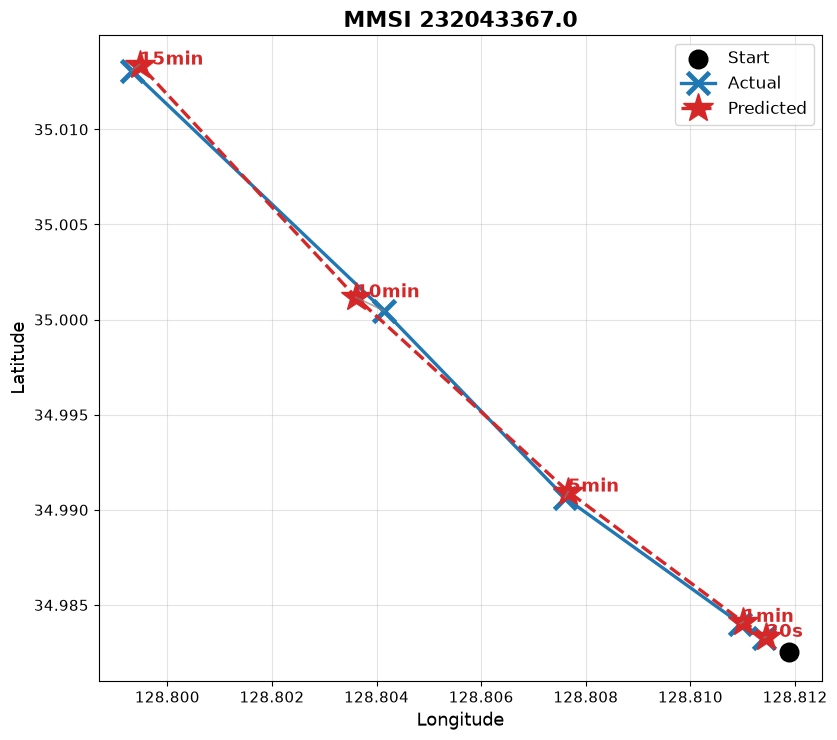

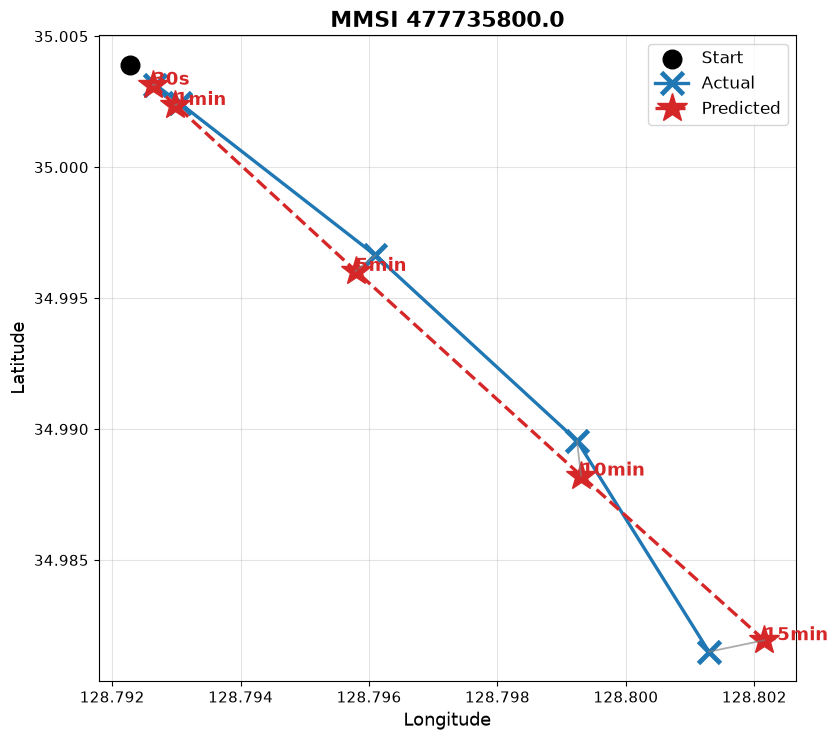

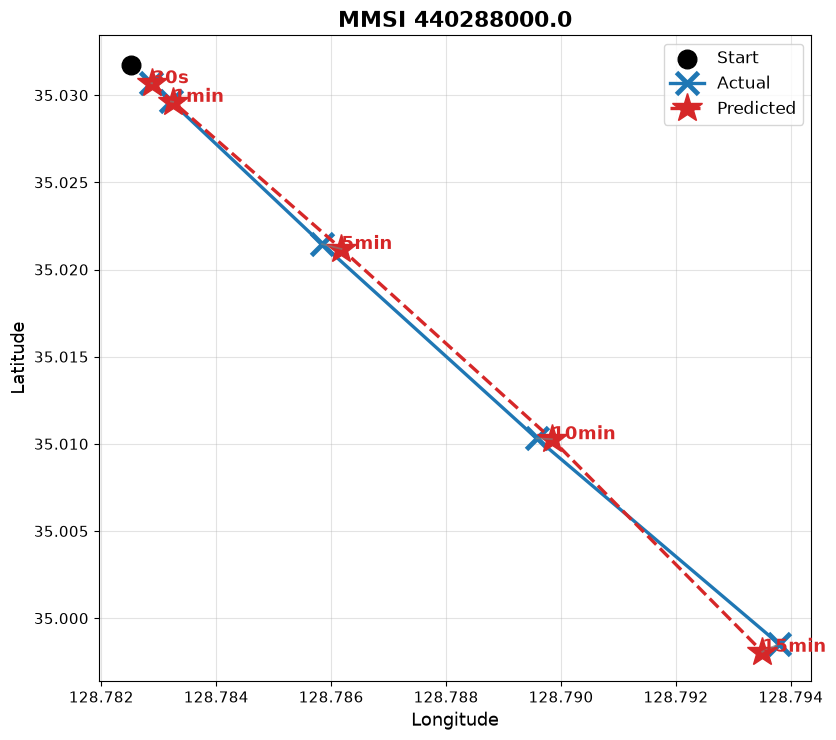

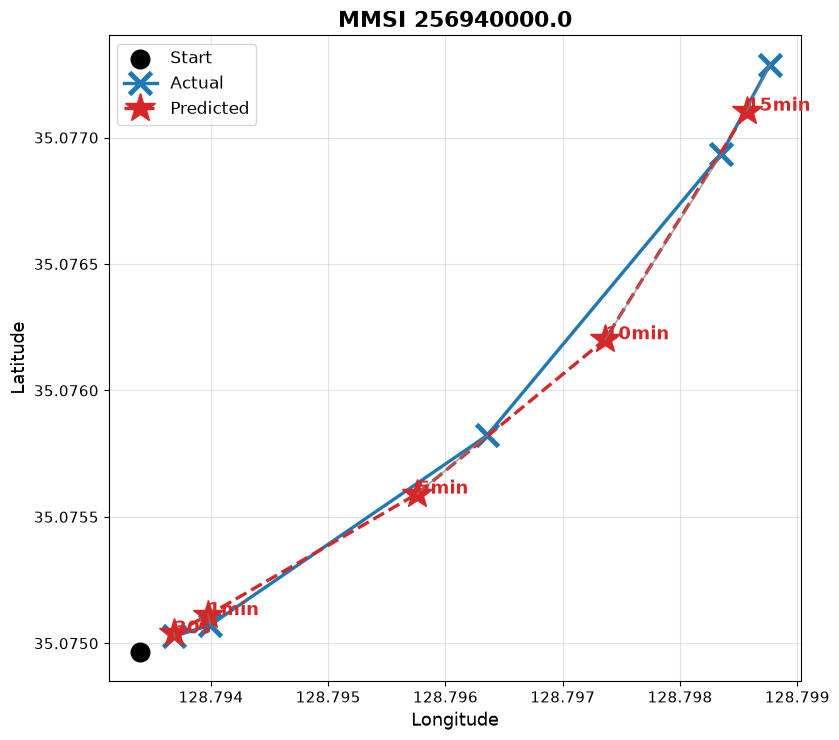

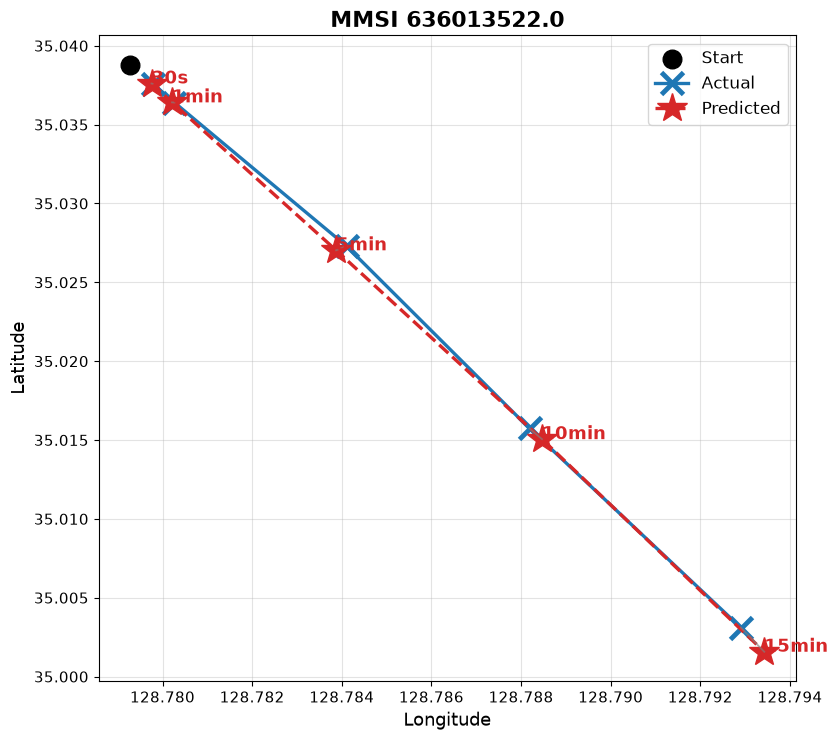

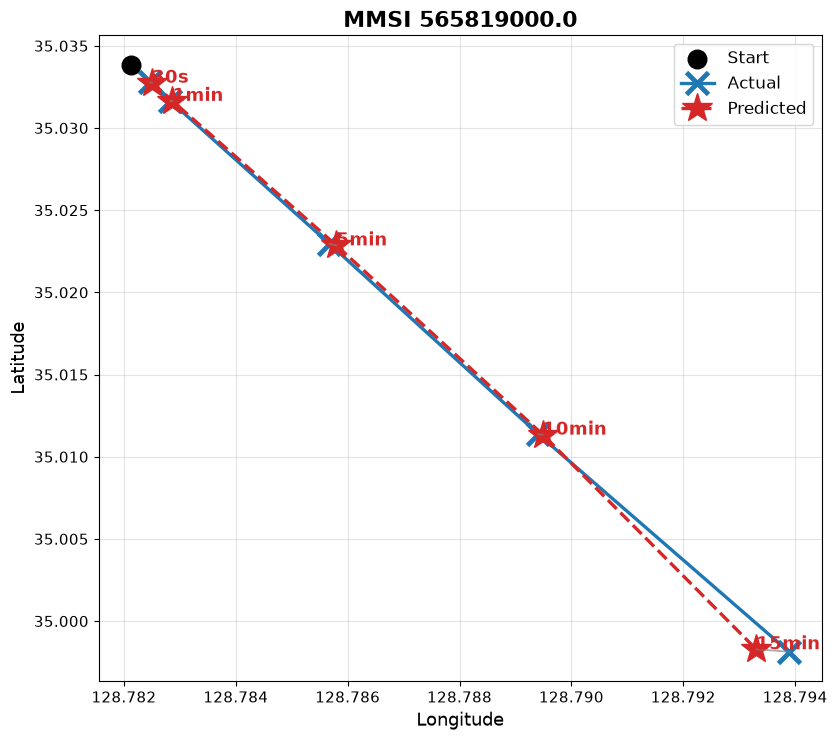

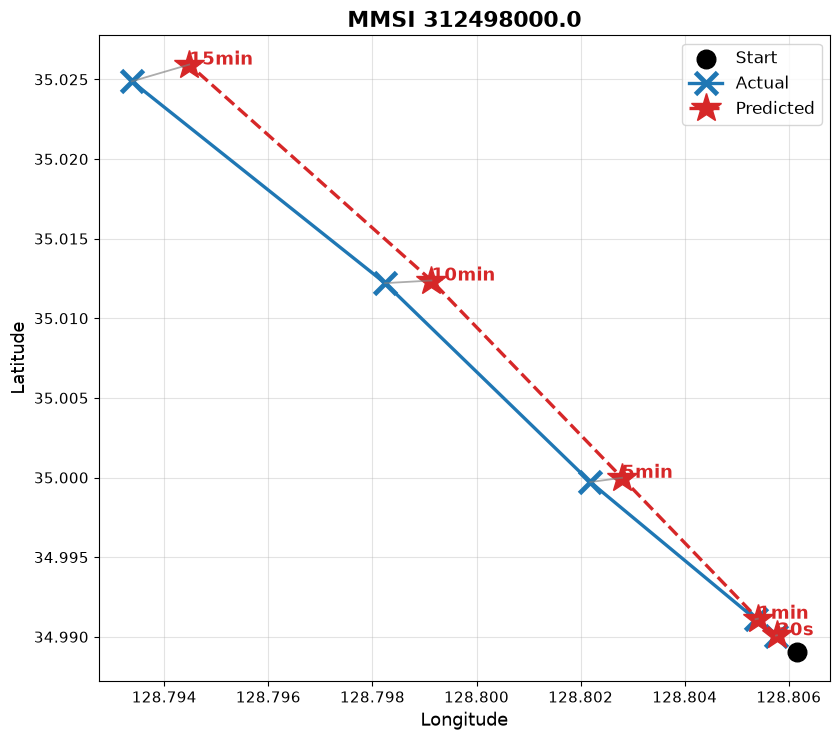

In [23]:
# 15분까지 예측 가능한 sample 중
# 실제 15분 누적 이동거리 >= 150m 필터
# 선박별 전체 평균오차 작은 순 + 30초 오차 작은 순 기준 상위 10척 표 + 그래프 출력

TOP_N = 10
FINAL_HORIZON_SECONDS = 900
SHORT_HORIZON_SECONDS = 30
MIN_ACTUAL_MOVE_15MIN_M = 150
PLOT_HORIZONS = [30, 60, 300, 600, 900]


def build_plot_df_from_results_and_paths(results_df, paths):
    result_df = results_df.copy().rename(columns={
        "MMSI": "mmsi",
        "actual_lat": "true_lat",
        "actual_lon": "true_lon"
    })

    start_rows = []

    for sample_index, item in enumerate(paths):
        start_rows.append({
            "sample_index": sample_index,
            "mmsi": item.get("MMSI"),
            "base_time": item.get("base_time"),
            "last_lat": item.get("start_lat"),
            "last_lon": item.get("start_lon"),
            "path_start_sog": item.get("start_sog", np.nan)
        })

    start_df = pd.DataFrame(start_rows)

    result_df = result_df.merge(
        start_df,
        on=["mmsi", "base_time"],
        how="inner",
        suffixes=("", "_path")
    )

    if "start_sog" not in result_df.columns:
        if "start_sog_x" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_x"]
        elif "start_sog_y" in result_df.columns:
            result_df["start_sog"] = result_df["start_sog_y"]
        elif "path_start_sog" in result_df.columns:
            result_df["start_sog"] = result_df["path_start_sog"]
        else:
            result_df["start_sog"] = np.nan

    if "path_start_sog" in result_df.columns:
        result_df["start_sog"] = result_df["start_sog"].fillna(result_df["path_start_sog"])

    return result_df.dropna(
        subset=[
            "sample_index",
            "mmsi",
            "base_time",
            "forecast_seconds",
            "pred_lat",
            "pred_lon",
            "true_lat",
            "true_lon",
            "error_m",
            "last_lat",
            "last_lon"
        ]
    )


def add_actual_move_15min(plot_df):
    df = plot_df.copy()

    final_df = df[df["forecast_seconds"] == FINAL_HORIZON_SECONDS].copy()

    final_df["actual_move_15min_m"] = haversine_km(
        final_df["last_lat"],
        final_df["last_lon"],
        final_df["true_lat"],
        final_df["true_lon"]
    ) * 1000

    final_df = final_df[[
        "sample_index",
        "actual_move_15min_m"
    ]]

    df = df.merge(
        final_df,
        on="sample_index",
        how="left"
    )

    return df


plot_df_rank = build_plot_df_from_results_and_paths(
    test_trajectory_results_df,
    test_trajectory_paths
)

plot_df_rank = add_actual_move_15min(plot_df_rank)

# 1. 15분까지 예측 가능 + 실제 15분 이동거리 필터
valid_df = plot_df_rank[
    (plot_df_rank["forecast_seconds"].isin(PLOT_HORIZONS))
    & (plot_df_rank["actual_move_15min_m"] >= MIN_ACTUAL_MOVE_15MIN_M)
].copy()

# sample마다 5개 horizon이 모두 있는 sample만 사용
sample_valid_count_df = (
    valid_df
    .groupby("sample_index")
    .agg(
        horizon_count=("forecast_seconds", "nunique"),
        max_horizon=("forecast_seconds", "max"),
        mmsi=("mmsi", "first"),
        base_time=("base_time", "first"),
        actual_move_15min_m=("actual_move_15min_m", "first")
    )
    .reset_index()
)

valid_sample_df = sample_valid_count_df[
    (sample_valid_count_df["horizon_count"] >= len(PLOT_HORIZONS))
    & (sample_valid_count_df["max_horizon"] >= FINAL_HORIZON_SECONDS)
].copy()

if len(valid_sample_df) == 0:
    raise ValueError("15분까지 예측 가능하고 실제 15분 이동거리 150m 이상인 sample이 없습니다.")

valid_df = valid_df[
    valid_df["sample_index"].isin(valid_sample_df["sample_index"])
].copy()


# 2. sample별 전체 평균오차 + 30초 오차 계산
sample_mean_df = (
    valid_df
    .groupby("sample_index")
    .agg(
        mmsi=("mmsi", "first"),
        base_time=("base_time", "first"),
        sample_mean_error_m=("error_m", "mean"),
        sample_median_error_m=("error_m", "median"),
        sample_max_error_m=("error_m", "max"),
        actual_move_15min_m=("actual_move_15min_m", "first"),
        start_sog=("start_sog", "first")
    )
    .reset_index()
)

sample_30s_df = (
    valid_df[valid_df["forecast_seconds"] == SHORT_HORIZON_SECONDS]
    [["sample_index", "error_m"]]
    .rename(columns={"error_m": "sample_30s_error_m"})
)

sample_score_df = sample_mean_df.merge(
    sample_30s_df,
    on="sample_index",
    how="inner"
)


# 3. 선박별 전체 평균오차 + 30초 최소오차 계산
vessel_score_df = (
    sample_score_df
    .groupby("mmsi")
    .agg(
        vessel_mean_error_m=("sample_mean_error_m", "mean"),
        vessel_median_error_m=("sample_median_error_m", "median"),
        vessel_best_30s_error_m=("sample_30s_error_m", "min"),
        vessel_mean_30s_error_m=("sample_30s_error_m", "mean"),
        sample_count=("sample_index", "nunique"),
        mean_actual_move_15min_m=("actual_move_15min_m", "mean"),
        mean_start_sog=("start_sog", "mean")
    )
    .reset_index()
)

vessel_score_df = vessel_score_df.sort_values(
    ["vessel_mean_error_m", "vessel_best_30s_error_m"],
    ascending=[True, True]
)

top10_vessels_df = vessel_score_df.head(TOP_N).copy()
top10_vessels_df["rank"] = np.arange(1, len(top10_vessels_df) + 1)


# 4. 각 선박의 대표 sample 선택
# 기준: 해당 선박 내에서 sample 평균오차 작은 순 + 30초 오차 작은 순
representative_rows = []

for _, vessel_row in top10_vessels_df.iterrows():
    mmsi = vessel_row["mmsi"]

    vessel_samples = sample_score_df[
        sample_score_df["mmsi"] == mmsi
    ].copy()

    vessel_samples = vessel_samples.sort_values(
        ["sample_mean_error_m", "sample_30s_error_m"],
        ascending=[True, True]
    )

    best_sample = vessel_samples.iloc[0]

    representative_rows.append({
        "rank": vessel_row["rank"],
        "mmsi": mmsi,
        "sample_index": best_sample["sample_index"],
        "base_time": best_sample["base_time"],
        "sample_mean_error_m": best_sample["sample_mean_error_m"],
        "sample_median_error_m": best_sample["sample_median_error_m"],
        "sample_30s_error_m": best_sample["sample_30s_error_m"],
        "sample_max_error_m": best_sample["sample_max_error_m"],
        "vessel_mean_error_m": vessel_row["vessel_mean_error_m"],
        "vessel_median_error_m": vessel_row["vessel_median_error_m"],
        "vessel_best_30s_error_m": vessel_row["vessel_best_30s_error_m"],
        "sample_count": vessel_row["sample_count"],
        "actual_move_15min_m": best_sample["actual_move_15min_m"],
        "mean_actual_move_15min_m": vessel_row["mean_actual_move_15min_m"],
        "start_sog": best_sample["start_sog"]
    })

top10_representative_df = pd.DataFrame(representative_rows)


# 5. 결과 표 출력
print("조건: 15분 예측 가능 + 실제 15분 이동거리 >= 150m")
print("정렬: 선박별 전체 평균오차 작은 순 + 30초 오차 작은 순")

display(
    top10_vessels_df[[
        "rank",
        "mmsi",
        "vessel_mean_error_m",
        "vessel_median_error_m",
        "vessel_best_30s_error_m",
        "vessel_mean_30s_error_m",
        "sample_count",
        "mean_actual_move_15min_m",
        "mean_start_sog"
    ]].round(2)
)

print("그래프에 사용할 대표 sample")
display(
    top10_representative_df[[
        "rank",
        "mmsi",
        "base_time",
        "sample_mean_error_m",
        "sample_30s_error_m",
        "sample_median_error_m",
        "sample_max_error_m",
        "actual_move_15min_m",
        "start_sog"
    ]].round(2)
)


# 6. 각 대표 sample의 horizon별 오차표
horizon_error_rows = []

for _, sample_row in top10_representative_df.iterrows():
    group = valid_df[
        valid_df["sample_index"] == sample_row["sample_index"]
    ].sort_values("forecast_seconds")

    for _, row in group.iterrows():
        if row["forecast_seconds"] < 60:
            horizon_label = f"{int(row['forecast_seconds'])}s"
        else:
            horizon_label = f"{row['forecast_minutes']:.0f}min"

        horizon_error_rows.append({
            "rank": sample_row["rank"],
            "MMSI": sample_row["mmsi"],
            "horizon": horizon_label,
            "error_m": row["error_m"],
            "actual_move_15min_m": row["actual_move_15min_m"],
            "base_time": row["base_time"]
        })

top10_horizon_error_df = pd.DataFrame(horizon_error_rows)

print("상위 10척 대표 sample의 예측시점별 거리오차")
display(
    top10_horizon_error_df.round({
        "error_m": 2,
        "actual_move_15min_m": 2
    })
)


# 7. 그래프 출력
def plot_ranked_vessel_trajectory(plot_df, representative_row):
    sample_index = representative_row["sample_index"]
    rank = int(representative_row["rank"])
    mmsi = representative_row["mmsi"]

    group = plot_df[
        (plot_df["sample_index"] == sample_index)
        & (plot_df["forecast_seconds"].isin(PLOT_HORIZONS))
    ].copy()

    group = group.sort_values("forecast_seconds")

    if len(group) == 0:
        return

    plt.figure(figsize=(8.5, 7.5))

    plt.scatter(
        group.iloc[0]["last_lon"],
        group.iloc[0]["last_lat"],
        color="black",
        marker="o",
        s=180,
        label="Start",
        zorder=5
    )

    plt.plot(
        group["true_lon"],
        group["true_lat"],
        color="tab:blue",
        linestyle="-",
        marker="x",
        linewidth=2.4,
        markersize=16,
        markeredgewidth=3.5,
        label="Actual"
    )

    plt.plot(
        group["pred_lon"],
        group["pred_lat"],
        color="tab:red",
        linestyle="--",
        marker="*",
        linewidth=2.4,
        markersize=22,
        label="Predicted"
    )

    for _, row in group.iterrows():
        plt.plot(
            [row["true_lon"], row["pred_lon"]],
            [row["true_lat"], row["pred_lat"]],
            color="gray",
            alpha=0.65,
            linewidth=1.3
        )

        if row["forecast_seconds"] < 60:
            label = f"{int(row['forecast_seconds'])}s"
        else:
            label = f"{row['forecast_minutes']:.0f}min"

        plt.text(
            row["pred_lon"],
            row["pred_lat"],
            label,
            fontsize=13,
            fontweight="bold",
            color="tab:red"
        )

    plt.title(f"MMSI {mmsi}", fontsize=16, fontweight="bold")
    plt.xlabel("Longitude", fontsize=13)
    plt.ylabel("Latitude", fontsize=13)
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=12)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")
    ax.tick_params(axis="both", labelsize=11)

    plt.tight_layout()
    plt.show()


for _, row in top10_representative_df.iterrows():
    plot_ranked_vessel_trajectory(valid_df, row)